# 🛒 E-Commerce Order Fulfillment Efficiency
## Task 2: Exploratory Data Analysis (EDA) & Business Intelligence

---

Dataset : Olist Brazilian E-Commerce Public Dataset

Tool : Python (Pandas, Matplotlib, Seaborn) + SQL (SQLite)

---

### 🎯 Objective
Uncover patterns, trends, and relationships within the order fulfillment lifecycle.  
Answer 7 key operational business questions using SQL.  
Identify bottlenecks across approval, shipping, and delivery stages.

---

### 📦 Datasets Used
- `olist_orders_dataset.csv` — Core order lifecycle timestamps  
- `olist_order_items_dataset.csv` — Order to product/seller mapping  
- `olist_products_dataset.csv` — Product dimensions and category  
- `olist_sellers_dataset.csv` — Seller location data  
- `olist_customers_dataset.csv` — Customer location data  
- `product_category_name_translation.csv` — Category name translation

In [26]:
# ============================================================
# IMPORTS & CONFIGURATION
# ============================================================

# --- Core Libraries ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- SQL Engine ---
import sqlite3

# --- System ---
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# VISUAL THEME CONFIGURATION
# ============================================================

# Color palette for consistent visuals throughout the notebook
COLORS = {
    'primary'   : '#4361EE',
    'secondary' : '#F72585',
    'accent'    : '#4CC9F0',
    'warning'   : '#F4A261',
    'success'   : '#2DC653',
    'neutral'   : '#6C757D'
}

PALETTE = [COLORS['primary'], COLORS['secondary'], COLORS['accent'],
           COLORS['warning'], COLORS['success'], COLORS['neutral']]

# Global plot settings
plt.rcParams['figure.figsize']    = (13, 5)
plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size']         = 11

sns.set_theme(style='darkgrid', palette=PALETTE)

print("All libraries loaded successfully")
print(f"   Pandas    : {pd.__version__}")
print(f"   NumPy     : {np.__version__}")
print(f"   Seaborn   : {sns.__version__}")

All libraries loaded successfully
   Pandas    : 2.2.2
   NumPy     : 2.0.2
   Seaborn   : 0.13.2


In [27]:
# ============================================================
# DATA LOADING
# ============================================================

# --- Load Cleaned Dataset from Task 1 ---
df = pd.read_excel('Cleaned Orders Dataset.xlsx', parse_dates=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

# --- Load Supporting Datasets ---
items_df       = pd.read_csv('olist_order_items_dataset.csv')
products_df    = pd.read_csv('olist_products_dataset.csv')
sellers_df     = pd.read_csv('olist_sellers_dataset.csv')
customers_df   = pd.read_csv('olist_customers_dataset.csv')
translation_df = pd.read_csv('product_category_name_translation.csv')

datasets = {
    'Cleaned Orders (Task 1)' : df,
    'Order Items'             : items_df,
    'Products'                : products_df,
    'Sellers'                 : sellers_df,
    'Customers'               : customers_df,
    'Category Translation'    : translation_df
}

print("=" * 60)
print("       DATASET LOADING SUMMARY")
print("=" * 60)
for name, dataset in datasets.items():
    print(f"  ✅ {name:<30} {dataset.shape[0]:>7,} rows  |  {dataset.shape[1]:>2} cols")
print("=" * 60)

       DATASET LOADING SUMMARY
  ✅ Cleaned Orders (Task 1)         96,476 rows  |  11 cols
  ✅ Order Items                    112,650 rows  |   7 cols
  ✅ Products                        32,951 rows  |   9 cols
  ✅ Sellers                          3,095 rows  |   4 cols
  ✅ Customers                       99,441 rows  |   5 cols
  ✅ Category Translation                71 rows  |   2 cols


In [28]:
required_columns = ['delivery_days', 'shipping_days', 'approval_delay']

print("=== CHECKING TASK 1 ENGINEERED FEATURES ===")

all_good = True
for col in required_columns:
    if col in df.columns:
        print(f"  ✅ '{col}' found — mean: {df[col].mean():.2f} days")
    else:
        print(f"  ❌ '{col}' MISSING — needs to be added")
        all_good = False

print()
if all_good:
    print("All engineered features confirmed. Ready for EDA.")
else:
    print("⚠️  Some features are missing. Re-run Task 1 cleaning first.")

print(f"\nTotal orders in cleaned dataset: {len(df):,}")
print(f"Date range: {df['order_purchase_timestamp'].min().date()} "
      f"→ {df['order_purchase_timestamp'].max().date()}")

=== CHECKING TASK 1 ENGINEERED FEATURES ===
  ✅ 'delivery_days' found — mean: 12.56 days
  ✅ 'shipping_days' found — mean: 12.29 days
  ✅ 'approval_delay' found — mean: 0.43 days

All engineered features confirmed. Ready for EDA.

Total orders in cleaned dataset: 96,476
Date range: 2016-09-15 → 2018-08-29


In [29]:
# ============================================================
# DIAGNOSE FEATURE CALCULATION
# ============================================================

print("============ VERIFYING FEATURE CALCULATIONS ============\n")

# Recalculate all three from scratch to verify
df['_delivery_days_check'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

df['_shipping_days_check'] = (
    df['order_delivered_carrier_date'] - df['order_purchase_timestamp']
).dt.days

df['_approval_delay_check'] = (
    df['order_approved_at'] - df['order_purchase_timestamp']
).dt.days

# Compare
print(f"  delivery_days  — Existing: {df['delivery_days'].mean():.2f}  |  Recalculated: {df['_delivery_days_check'].mean():.2f}")
print(f"  shipping_days  — Existing: {df['shipping_days'].mean():.2f}  |  Recalculated: {df['_shipping_days_check'].mean():.2f}")
print(f"  approval_delay — Existing: {df['approval_delay'].mean():.2f}  |  Recalculated: {df['_approval_delay_check'].mean():.2f}")

print("\n=== SAMPLE COMPARISON (first 5 rows) ===")
df[[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'delivery_days',
    '_delivery_days_check',
    'shipping_days',
    '_shipping_days_check'
]].head()

============ VERIFYING FEATURE CALCULATIONS ============

  delivery_days  — Existing: 12.56  |  Recalculated: 12.09
  shipping_days  — Existing: 12.29  |  Recalculated: 2.74
  approval_delay — Existing: 0.43  |  Recalculated: 0.27

=== SAMPLE COMPARISON (first 5 rows) ===


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,delivery_days,_delivery_days_check,shipping_days,_shipping_days_check
0,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,8.436806,8,2.374306,2.0
1,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,13.781944,13,1.743056,1.0
2,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,9.394444,9,0.216667,0.0
3,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,13.208333,13,3.757639,3.0
4,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2.874306,2,0.936111,0.0


In [30]:
# ============================================================
# CELL 6 | FIX & STANDARDIZE ENGINEERED FEATURES
# ============================================================

# Drop the temporary check columns
df.drop(columns=[
    '_delivery_days_check',
    '_shipping_days_check',
    '_approval_delay_check'
], inplace=True)

# Recalculate all features using fractional days (total_seconds / 86400)
df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.total_seconds() / 86400

df['shipping_days'] = (
    df['order_delivered_carrier_date'] - df['order_purchase_timestamp']
).dt.total_seconds() / 86400

df['approval_delay'] = (
    df['order_approved_at'] - df['order_purchase_timestamp']
).dt.total_seconds() / 86400

# ============================================================
# VERIFY THE FIX
# ============================================================

print("=== STANDARDIZED FEATURE SUMMARY ===\n")
print(f"  {'Feature':<20} {'Mean':>8}  {'Median':>8}  {'Min':>8}  {'Max':>8}")
print(f"  {'-'*56}")

for col in ['delivery_days', 'shipping_days', 'approval_delay']:
    print(f"  {col:<20} "
          f"{df[col].mean():>8.2f}  "
          f"{df[col].median():>8.2f}  "
          f"{df[col].min():>8.2f}  "
          f"{df[col].max():>8.2f}")

print(f"\n  ✅ delivery_days mean should be GREATER than shipping_days mean")
print(f"  ✅ Check: {df['delivery_days'].mean():.2f} > {df['shipping_days'].mean():.2f} "
      f"→ {'PASS ✅' if df['delivery_days'].mean() > df['shipping_days'].mean() else 'FAIL ❌'}")

# ============================================================
# ADD ONE MORE FEATURE WE'LL NEED FOR EDA
# ============================================================

# Was the order delivered on time or late?
df['delivery_status'] = np.where(
    df['order_delivered_customer_date'] <= df['order_estimated_delivery_date'],
    'On Time',
    'Late'
)

# How many days early (negative) or late (positive) vs estimate?
df['delivery_deviation'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.total_seconds() / 86400

print(f"\n=== DELIVERY STATUS DISTRIBUTION ===\n")
status_counts = df['delivery_status'].value_counts()
for status, count in status_counts.items():
    pct = count / len(df) * 100
    print(f"  {status:<10} : {count:>6,} orders  ({pct:.1f}%)")

print(f"\n✅ Two new features added: 'delivery_status' & 'delivery_deviation'")
print(f"📊 Dataset now has {df.shape[1]} columns and {df.shape[0]:,} rows")

=== STANDARDIZED FEATURE SUMMARY ===

  Feature                  Mean    Median       Min       Max
  --------------------------------------------------------
  delivery_days           12.56     10.22      0.53    209.63
  shipping_days            3.23      2.20   -171.21    125.78
  approval_delay           0.43      0.01      0.00     30.89

  ✅ delivery_days mean should be GREATER than shipping_days mean
  ✅ Check: 12.56 > 3.23 → PASS ✅

=== DELIVERY STATUS DISTRIBUTION ===

  On Time    : 88,649 orders  (91.9%)
  Late       :  7,827 orders  (8.1%)

✅ Two new features added: 'delivery_status' & 'delivery_deviation'
📊 Dataset now has 13 columns and 96,476 rows


In [31]:
# ============================================================
# HANDLE DATA ANOMALIES
# ============================================================

print("=== ANOMALY INVESTIGATION ===\n")

# Check negative shipping days
negative_shipping = df[df['shipping_days'] < 0]
print(f"  Orders with negative shipping_days : {len(negative_shipping):,}")
print(f"  This represents                    : {len(negative_shipping)/len(df)*100:.2f}% of dataset")

print(f"\n  Sample of anomalous records:")
print(negative_shipping[[
    'order_purchase_timestamp',
    'order_delivered_carrier_date',
    'shipping_days'
]].head(3).to_string(index=False))

# ---- Decision: Remove negative shipping_days ----
# These represent impossible fulfillment timelines
# Keeping them would distort all shipping-related analysis

df_clean = df[df['shipping_days'] >= 0].copy()

print(f"\n=== AFTER ANOMALY REMOVAL ===")
print(f"  Records removed : {len(df) - len(df_clean):,}")
print(f"  Records retained: {len(df_clean):,}")
print(f"  Data retained   : {len(df_clean)/len(df)*100:.2f}%")

print(f"\n=== UPDATED FEATURE SUMMARY ===\n")
print(f"  {'Feature':<20} {'Mean':>8}  {'Median':>8}  {'Min':>8}  {'Max':>8}")
print(f"  {'-'*56}")
for col in ['delivery_days', 'shipping_days', 'approval_delay']:
    print(f"  {col:<20} "
          f"{df_clean[col].mean():>8.2f}  "
          f"{df_clean[col].median():>8.2f}  "
          f"{df_clean[col].min():>8.2f}  "
          f"{df_clean[col].max():>8.2f}")

=== ANOMALY INVESTIGATION ===

  Orders with negative shipping_days : 160
  This represents                    : 0.17% of dataset

  Sample of anomalous records:
order_purchase_timestamp order_delivered_carrier_date  shipping_days
     2018-08-16 13:50:00          2018-08-16 13:27:00      -0.015972
     2018-06-15 15:41:00          2018-06-15 14:52:00      -0.034028
     2018-05-02 10:48:00          2018-05-02 09:49:00      -0.040972

=== AFTER ANOMALY REMOVAL ===
  Records removed : 161
  Records retained: 96,315
  Data retained   : 99.83%

=== UPDATED FEATURE SUMMARY ===

  Feature                  Mean    Median       Min       Max
  --------------------------------------------------------
  delivery_days           12.57     10.22      0.53    209.63
  shipping_days            3.24      2.21      0.00    125.78
  approval_delay           0.43      0.01      0.00     30.89


In [32]:
# ============================================================
# PHASE 1: DESCRIPTIVE STATISTICS
# ============================================================

print("=" * 65)
print("   PHASE 1: DESCRIPTIVE STATISTICS & UNIVARIATE ANALYSIS")
print("=" * 65)

features = ['delivery_days', 'shipping_days', 'approval_delay']

stats = df_clean[features].describe(percentiles=[.25, .50, .75, .90, .95]).T
stats.columns = ['Count', 'Mean', 'Std Dev', 'Min',
                 '25th %', 'Median', '75th %',
                 '90th %', '95th %', 'Max']

# Round for readability
stats = stats.round(2)

print("\n")
print(stats.to_string())

print("\n\n=== BUSINESS INTERPRETATION ===\n")

print(f"  📦 DELIVERY DAYS")
print(f"     50% of orders arrive within {df_clean['delivery_days'].median():.1f} days")
print(f"     90% of orders arrive within {df_clean['delivery_days'].quantile(0.90):.1f} days")
print(f"     Top 5% slowest orders take over {df_clean['delivery_days'].quantile(0.95):.1f} days")

print(f"\n  🚚 SHIPPING DAYS (Purchase → Carrier Handoff)")
print(f"     50% of orders reach carrier within {df_clean['shipping_days'].median():.1f} days")
print(f"     90% of orders reach carrier within {df_clean['shipping_days'].quantile(0.90):.1f} days")

print(f"\n  ✅ APPROVAL DELAY (Purchase → Approval)")
print(f"     50% of orders approved within {df_clean['approval_delay'].median()*24:.1f} hours")
print(f"     90% of orders approved within {df_clean['approval_delay'].quantile(0.90)*24:.1f} hours")
print(f"     Slowest 5% take over {df_clean['approval_delay'].quantile(0.95):.1f} days to approve")

   PHASE 1: DESCRIPTIVE STATISTICS & UNIVARIATE ANALYSIS


                  Count   Mean  Std Dev   Min  25th %  Median  75th %  90th %  95th %     Max
delivery_days   96315.0  12.57     9.55  0.53    6.77   10.22   15.73   23.10   29.29  209.63
shipping_days   96315.0   3.24     3.55  0.00    1.13    2.21    4.07    6.41    8.88  125.78
approval_delay  96301.0   0.43     0.86  0.00    0.01    0.01    0.61    1.44    2.01   30.89


=== BUSINESS INTERPRETATION ===

  📦 DELIVERY DAYS
     50% of orders arrive within 10.2 days
     90% of orders arrive within 23.1 days
     Top 5% slowest orders take over 29.3 days

  🚚 SHIPPING DAYS (Purchase → Carrier Handoff)
     50% of orders reach carrier within 2.2 days
     90% of orders reach carrier within 6.4 days

  ✅ APPROVAL DELAY (Purchase → Approval)
     50% of orders approved within 0.3 hours
     90% of orders approved within 34.6 hours
     Slowest 5% take over 2.0 days to approve


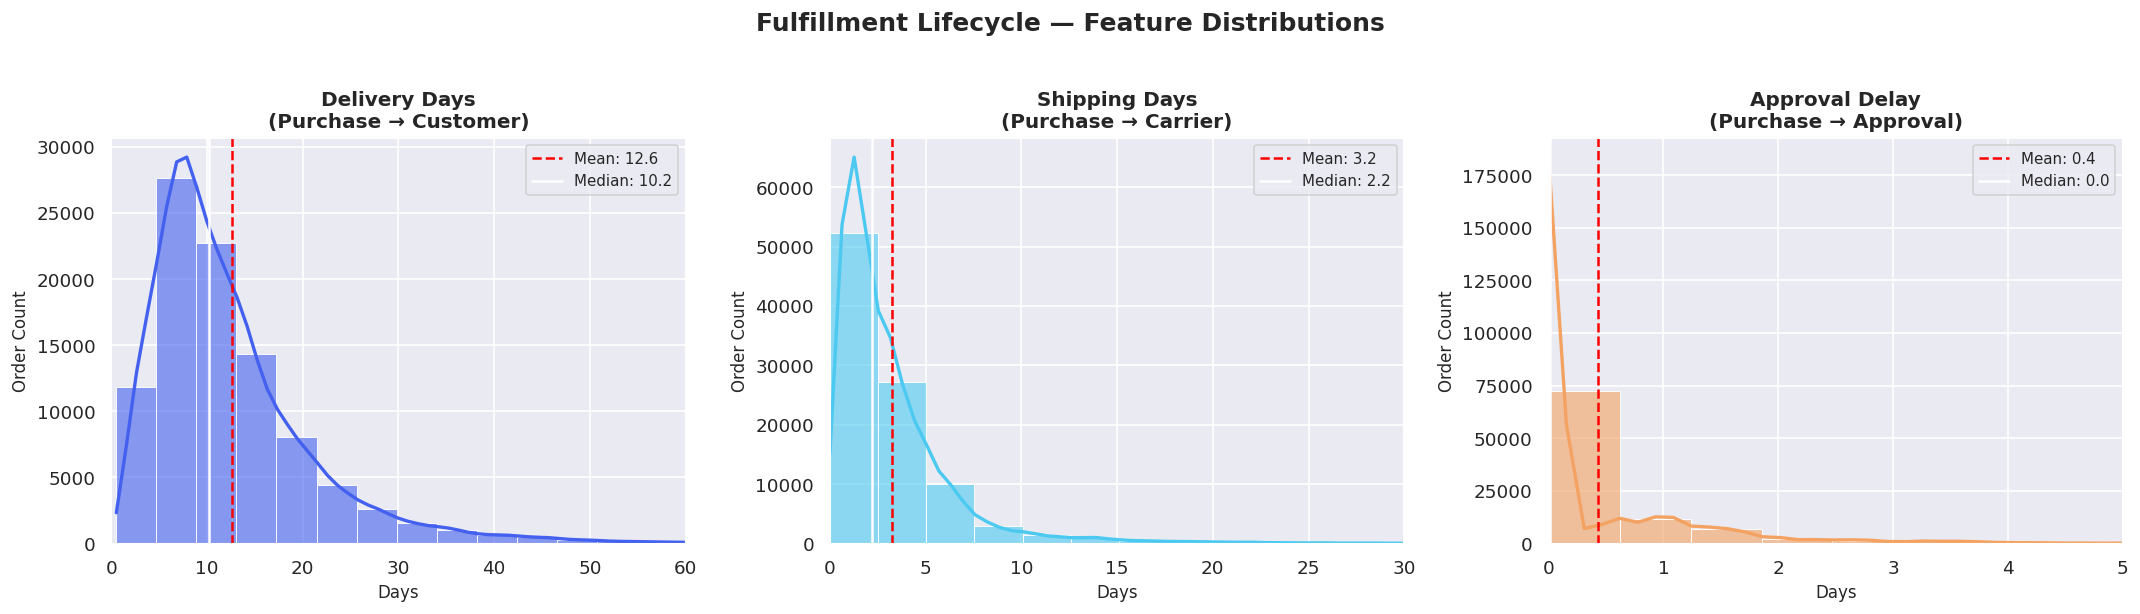

In [33]:
# ============================================================
# DISTRIBUTION PLOTS — UNIVARIATE ANALYSIS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fulfillment Lifecycle — Feature Distributions',
             fontsize=15, fontweight='bold', y=1.02)

plot_config = [
    {
        'col'   : 'delivery_days',
        'title' : 'Delivery Days\n(Purchase → Customer)',
        'color' : COLORS['primary'],
        'xlim'  : (0, 60)
    },
    {
        'col'   : 'shipping_days',
        'title' : 'Shipping Days\n(Purchase → Carrier)',
        'color' : COLORS['accent'],
        'xlim'  : (0, 30)
    },
    {
        'col'   : 'approval_delay',
        'title' : 'Approval Delay\n(Purchase → Approval)',
        'color' : COLORS['warning'],
        'xlim'  : (0, 5)
    }
]

for ax, cfg in zip(axes, plot_config):
    data = df_clean[cfg['col']]

    # Histogram + KDE
    sns.histplot(data, ax=ax, color=cfg['color'],
                 bins=50, kde=True, alpha=0.6,
                 line_kws={'linewidth': 2})

    # Mean and median lines
    ax.axvline(data.mean(),   color='red',    linestyle='--',
               linewidth=1.5, label=f"Mean: {data.mean():.1f}")
    ax.axvline(data.median(), color='white',  linestyle='-',
               linewidth=1.5, label=f"Median: {data.median():.1f}")

    ax.set_xlim(cfg['xlim'])
    ax.set_title(cfg['title'], fontweight='bold', fontsize=12)
    ax.set_xlabel('Days', fontsize=10)
    ax.set_ylabel('Order Count', fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


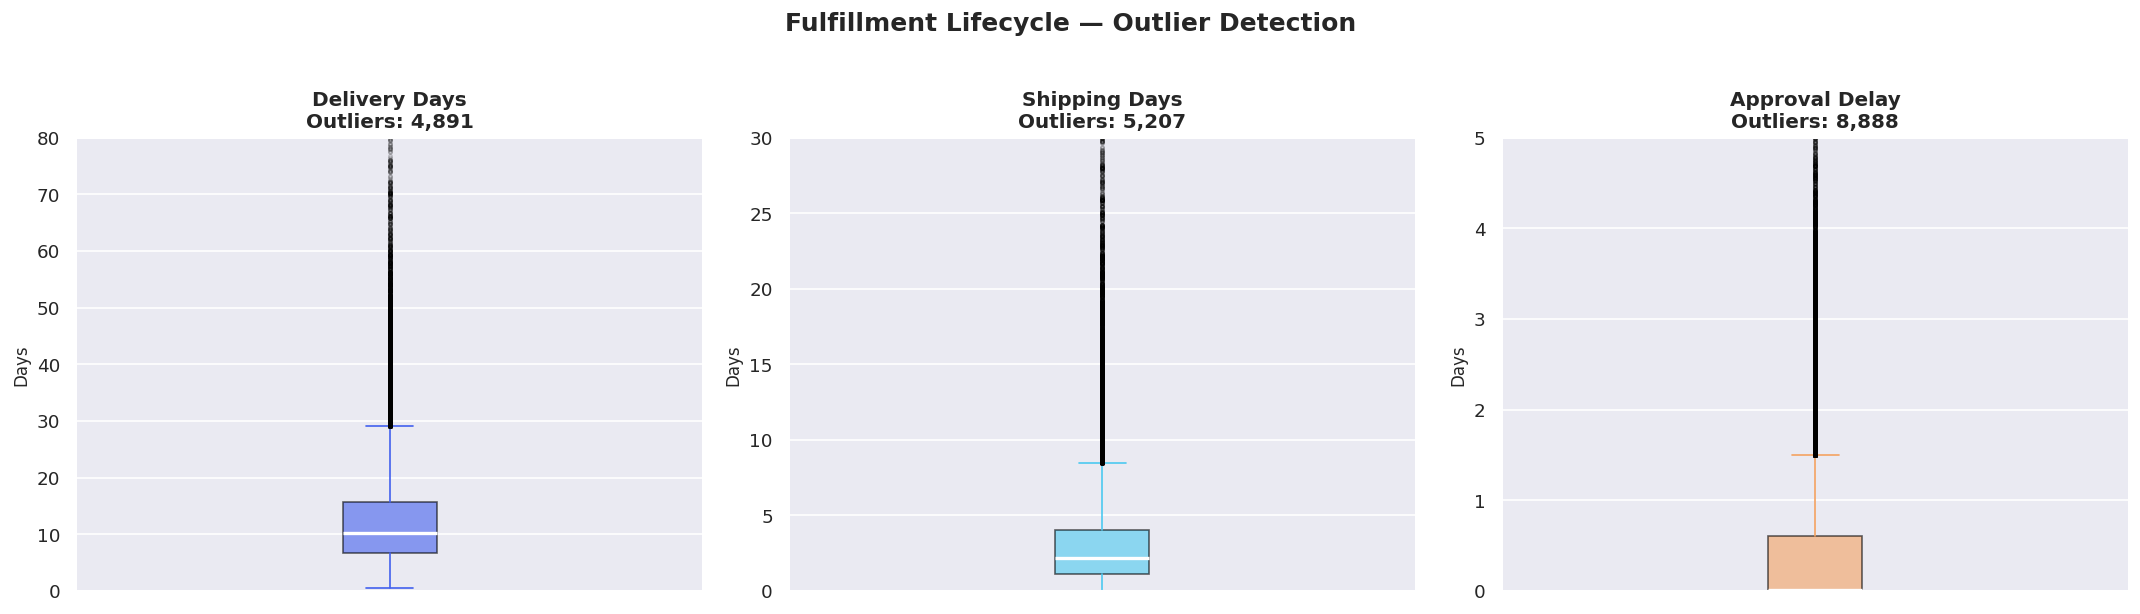

In [34]:
# ============================================================
# BOX PLOTS — OUTLIER VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Fulfillment Lifecycle — Outlier Detection',
             fontsize=15, fontweight='bold', y=1.02)

box_config = [
    ('delivery_days',  'Delivery Days',  COLORS['primary'], (0, 80)),
    ('shipping_days',  'Shipping Days',  COLORS['accent'],  (0, 30)),
    ('approval_delay', 'Approval Delay', COLORS['warning'], (0, 5))
]

for ax, (col, title, color, ylim) in zip(axes, box_config):
    data = df_clean[col]

    bp = ax.boxplot(data.dropna(),
                    patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color=color),
                    capprops=dict(color=color),
                    flierprops=dict(marker='o', color=color,
                                   alpha=0.2, markersize=2))

    # Annotations
    q1  = data.quantile(0.25)
    q3  = data.quantile(0.75)
    iqr = q3 - q1
    outlier_count = ((data < (q1 - 1.5*iqr)) |
                     (data > (q3 + 1.5*iqr))).sum()

    ax.set_title(f'{title}\nOutliers: {outlier_count:,}',
                 fontweight='bold', fontsize=12)
    ax.set_ylabel('Days', fontsize=10)
    ax.set_ylim(ylim)
    ax.set_xticks([])

plt.tight_layout()
plt.show()


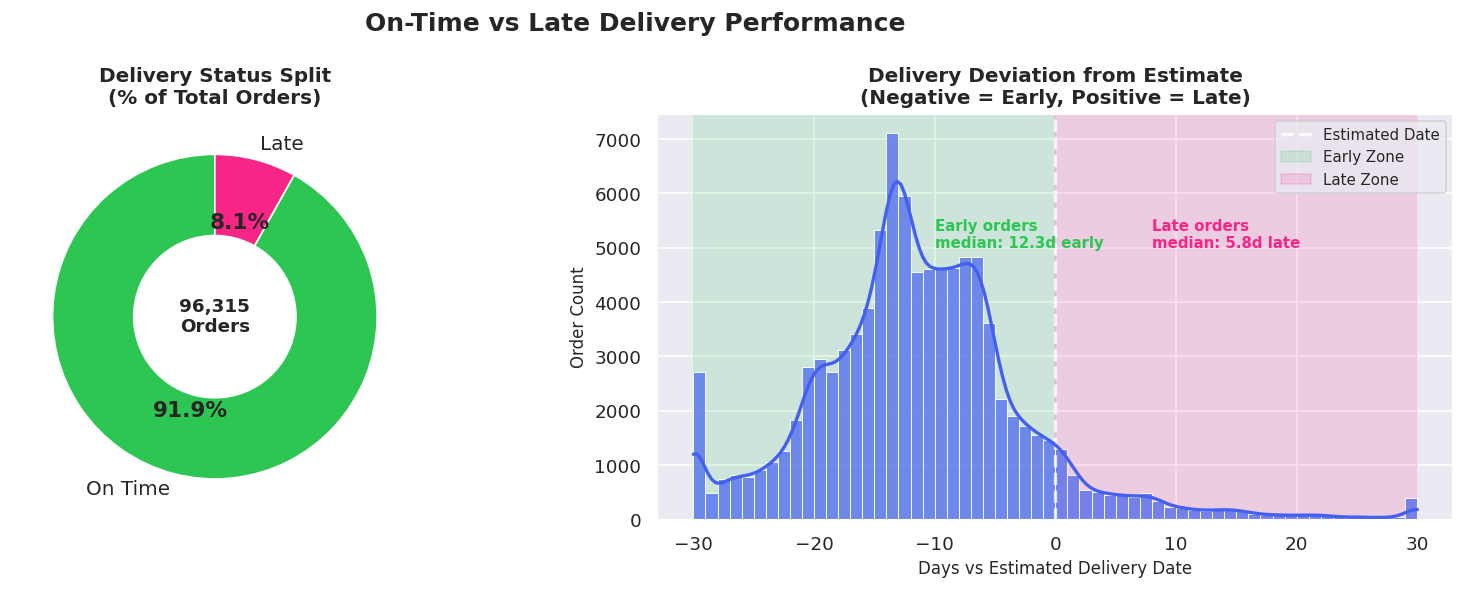

In [35]:
# ============================================================
# ON-TIME vs LATE DELIVERY BREAKDOWN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('On-Time vs Late Delivery Performance',
             fontsize=15, fontweight='bold')

# --- Chart A: Donut Chart ---
status_counts = df_clean['delivery_status'].value_counts()
colors_donut  = [COLORS['success'], COLORS['secondary']]

wedges, texts, autotexts = axes[0].pie(
    status_counts,
    labels    = status_counts.index,
    autopct   = '%1.1f%%',
    colors    = colors_donut,
    startangle= 90,
    wedgeprops= dict(width=0.5),
    textprops = dict(fontsize=12)
)

for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(13)

axes[0].set_title('Delivery Status Split\n(% of Total Orders)',
                  fontweight='bold', fontsize=12)

# Add center text
axes[0].text(0, 0, f"{len(df_clean):,}\nOrders",
             ha='center', va='center',
             fontsize=11, fontweight='bold')

# --- Chart B: Delivery Deviation Distribution ---
# How many days early (negative) or late (positive)?
deviation_clipped = df_clean['delivery_deviation'].clip(-30, 30)

axes[1].axvline(0, color='white', linestyle='--',
                linewidth=2, label='Estimated Date', alpha=0.8)
axes[1].axvspan(-30, 0, alpha=0.15, color=COLORS['success'],
                label='Early Zone')
axes[1].axvspan(0,  30, alpha=0.15, color=COLORS['secondary'],
                label='Late Zone')

sns.histplot(deviation_clipped, ax=axes[1], bins=60,
             color=COLORS['primary'], kde=True, alpha=0.7,
             line_kws={'linewidth': 2})

axes[1].set_title('Delivery Deviation from Estimate\n(Negative = Early, Positive = Late)',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Days vs Estimated Delivery Date', fontsize=10)
axes[1].set_ylabel('Order Count', fontsize=10)
axes[1].legend(fontsize=9)

# Annotations
early_median = df_clean[df_clean['delivery_deviation'] < 0]['delivery_deviation'].median()
late_median  = df_clean[df_clean['delivery_deviation'] > 0]['delivery_deviation'].median()

axes[1].annotate(f'Early orders\nmedian: {abs(early_median):.1f}d early',
                 xy=(-10, 5000), fontsize=9, color=COLORS['success'],
                 fontweight='bold')
axes[1].annotate(f'Late orders\nmedian: {late_median:.1f}d late',
                 xy=(8, 5000), fontsize=9, color=COLORS['secondary'],
                 fontweight='bold')

plt.tight_layout()
plt.show()

### 📊 Phase 1 — Key Findings

| Metric | Value | Insight |
|---|---|---|
| Median delivery time | 10.2 days | Operational benchmark |
| 90th percentile delivery | 23.1 days | SLA planning threshold |
| Median carrier handoff | 2.2 days | Sellers are efficient |
| Median approval time | ~18 minutes | Internal ops not a bottleneck |
| On-time delivery rate | 91.9% | Strong but 7,827 orders still late |
| Outlier delivery orders | 4,891 | Needs root cause investigation |

**Core Insight:** The fulfillment bottleneck is not internal (approval is fast)
and not seller dispatch (median 2.2 days). The problem lives in
**last-mile delivery** — the ~8 days between carrier pickup and customer door.
This is where Task 3 deep-dive analysis will focus.

In [36]:
# ============================================================
# SQL SETUP — LOAD DATAFRAMES INTO SQLITE
# ============================================================

# Create in-memory SQLite database
conn = sqlite3.connect(':memory:')

# --- Merge products with English category names first ---
products_translated = products_df.merge(
    translation_df,
    on='product_category_name',
    how='left'
)

# --- Load all tables into SQLite ---
df_clean.to_sql('orders', conn, index=False, if_exists='replace')
items_df.to_sql('order_items', conn, index=False, if_exists='replace')
products_translated.to_sql('products', conn, index=False, if_exists='replace')
sellers_df.to_sql('sellers', conn, index=False, if_exists='replace')
customers_df.to_sql('customers', conn, index=False, if_exists='replace')

# --- Verify tables loaded ---
tables = pd.read_sql_query("""
    SELECT name FROM sqlite_master
    WHERE type='table'
""", conn)

print("=== SQLITE DATABASE READY ===\n")
print("  Tables loaded:")
for table in tables['name']:
    count = pd.read_sql_query(
        f"SELECT COUNT(*) as rows FROM {table}", conn
    ).iloc[0,0]
    print(f"  📋 {table:<20} {count:>7,} rows")

print("\n✅ SQL engine ready. Beginning business queries.")

=== SQLITE DATABASE READY ===

  Tables loaded:
  📋 orders                96,315 rows
  📋 order_items          112,650 rows
  📋 products              32,951 rows
  📋 sellers                3,095 rows
  📋 customers             99,441 rows

✅ SQL engine ready. Beginning business queries.


---
## 🗄️ Phase 2: SQL for Business Questions

Using SQLite to answer 7 operational business questions.  
Each query is designed to surface a specific fulfillment insight.

| # | Business Question | Focus Area |
|---|---|---|
| Q1 | Which customer states have the worst delivery times? | Geography |
| Q2 | Which product categories take longest to deliver? | Product |
| Q3 | What % of orders were delivered before vs after estimate? | Performance |
| Q4 | What is the monthly trend of average delivery time? | Time |
| Q5 | Which sellers have the highest late delivery rate? | Seller |
| Q6 | How does approval delay vary by day of week? | Operations |
| Q7 | What is the relationship between shipping days and delivery days? | Correlation |

  Q1: TOP 15 STATES BY AVERAGE DELIVERY TIME
state  total_orders  avg_delivery_days  min_delivery_days  max_delivery_days  late_rate_pct
   AM           145              26.43               4.12             138.88           4.14
   AL           397              24.54               4.19              90.96          23.93
   PA           945              23.78               4.38             195.63          12.38
   MA           714              21.61               3.08             168.08          19.75
   SE           334              21.55               6.14             194.63          15.27
   CE          1278              21.27               2.85             168.18          15.34
   PB           517              20.43               5.73             102.17          11.03
   PI           473              19.51               2.03             194.85          16.07
   RO           243              19.37               7.88              50.78           2.88
   BA          3253              19

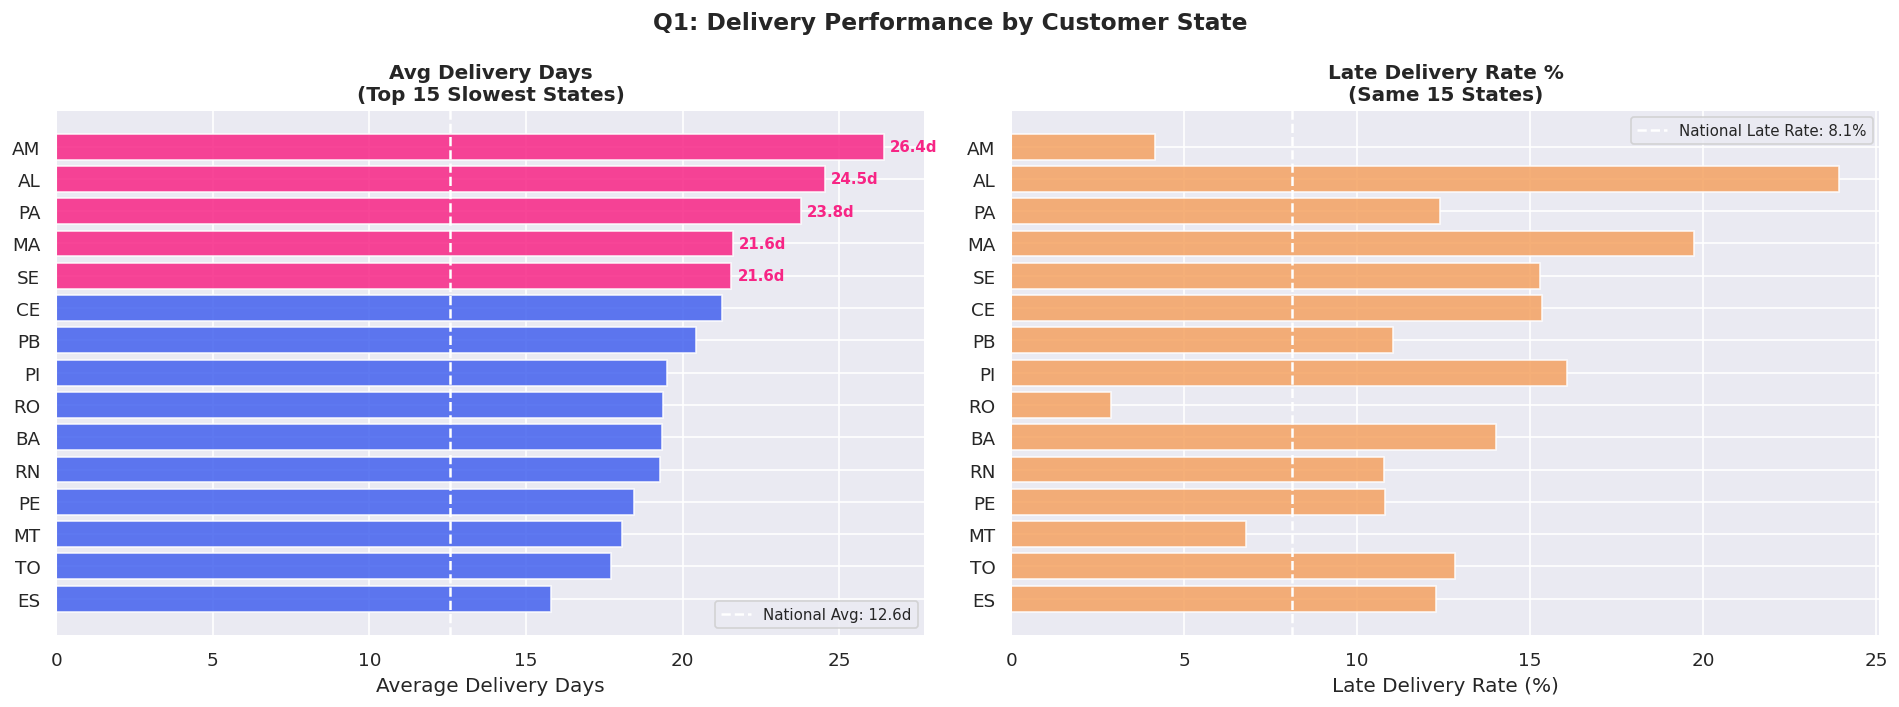


📍 INSIGHT:
   Worst state : AM — avg 26.43 days, 4.14% late rate
   15th state  : ES — avg 15.81 days
   Gap         : 10.6 days between worst and 15th


In [37]:
# ============================================================
# Q1: DELIVERY PERFORMANCE BY CUSTOMER STATE
# ============================================================
# Business Question:
# Which states are receiving orders slowest?
# Where should logistics investment be prioritized?
# ============================================================

q1 = """
    SELECT
        c.customer_state                            AS state,
        COUNT(o.order_id)                           AS total_orders,
        ROUND(AVG(o.delivery_days), 2)              AS avg_delivery_days,
        ROUND(MIN(o.delivery_days), 2)              AS min_delivery_days,
        ROUND(MAX(o.delivery_days), 2)              AS max_delivery_days,
        ROUND(
            100.0 * SUM(CASE WHEN o.delivery_status = 'Late'
                        THEN 1 ELSE 0 END)
            / COUNT(o.order_id), 2
        )                                           AS late_rate_pct
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    GROUP BY c.customer_state
    HAVING COUNT(o.order_id) >= 100
    ORDER BY avg_delivery_days DESC
    LIMIT 15
"""

q1_result = pd.read_sql_query(q1, conn)

print("=" * 65)
print("  Q1: TOP 15 STATES BY AVERAGE DELIVERY TIME")
print("=" * 65)
print(q1_result.to_string(index=False))

# ---- Visualization ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q1: Delivery Performance by Customer State',
             fontsize=14, fontweight='bold')

# Chart A — Average Delivery Days by State
colors_bar = [COLORS['secondary'] if i < 5 else COLORS['primary']
              for i in range(len(q1_result))]

axes[0].barh(q1_result['state'],
             q1_result['avg_delivery_days'],
             color=colors_bar, alpha=0.85)
axes[0].axvline(df_clean['delivery_days'].mean(),
                color='white', linestyle='--',
                linewidth=1.5, label=f"National Avg: {df_clean['delivery_days'].mean():.1f}d")
axes[0].set_title('Avg Delivery Days\n(Top 15 Slowest States)',
                  fontweight='bold')
axes[0].set_xlabel('Average Delivery Days')
axes[0].invert_yaxis()
axes[0].legend(fontsize=9)

# Highlight worst 5
for i, (val, state) in enumerate(zip(q1_result['avg_delivery_days'],
                                      q1_result['state'])):
    if i < 5:
        axes[0].text(val + 0.2, i, f'{val:.1f}d',
                    va='center', fontsize=9,
                    color=COLORS['secondary'], fontweight='bold')

# Chart B — Late Rate by State
axes[1].barh(q1_result['state'],
             q1_result['late_rate_pct'],
             color=COLORS['warning'], alpha=0.85)
axes[1].axvline(df_clean['delivery_status'].eq('Late').mean() * 100,
                color='white', linestyle='--',
                linewidth=1.5,
                label=f"National Late Rate: {df_clean['delivery_status'].eq('Late').mean()*100:.1f}%")
axes[1].set_title('Late Delivery Rate %\n(Same 15 States)',
                  fontweight='bold')
axes[1].set_xlabel('Late Delivery Rate (%)')
axes[1].invert_yaxis()
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ---- Business Interpretation ----
worst_state     = q1_result.iloc[0]
best_of_worst   = q1_result.iloc[-1]
print(f"\n📍 INSIGHT:")
print(f"   Worst state : {worst_state['state']} — "
      f"avg {worst_state['avg_delivery_days']} days, "
      f"{worst_state['late_rate_pct']}% late rate")
print(f"   15th state  : {best_of_worst['state']} — "
      f"avg {best_of_worst['avg_delivery_days']} days")
print(f"   Gap         : "
      f"{worst_state['avg_delivery_days'] - best_of_worst['avg_delivery_days']:.1f} days "
      f"between worst and 15th")

  Q2: TOP 15 PRODUCT CATEGORIES BY DELIVERY TIME
               category  total_orders  avg_delivery_days  avg_shipping_days  avg_lastmile_days  late_rate_pct
       office_furniture          1254              20.84              10.87               9.98           8.93
     christmas_supplies           125              15.74               3.31              12.43          12.00
          fashion_shoes           235              15.44               5.56               9.88           5.84
      home_appliances_2           226              13.94               4.63               9.31           6.96
  furniture_living_room           413              13.81               3.83               9.98           7.89
           garden_tools          3441              13.71               3.21              10.50           7.96
fashion_underwear_beach           117              13.71               4.23               9.48          12.60
         consoles_games          1017              13.62               

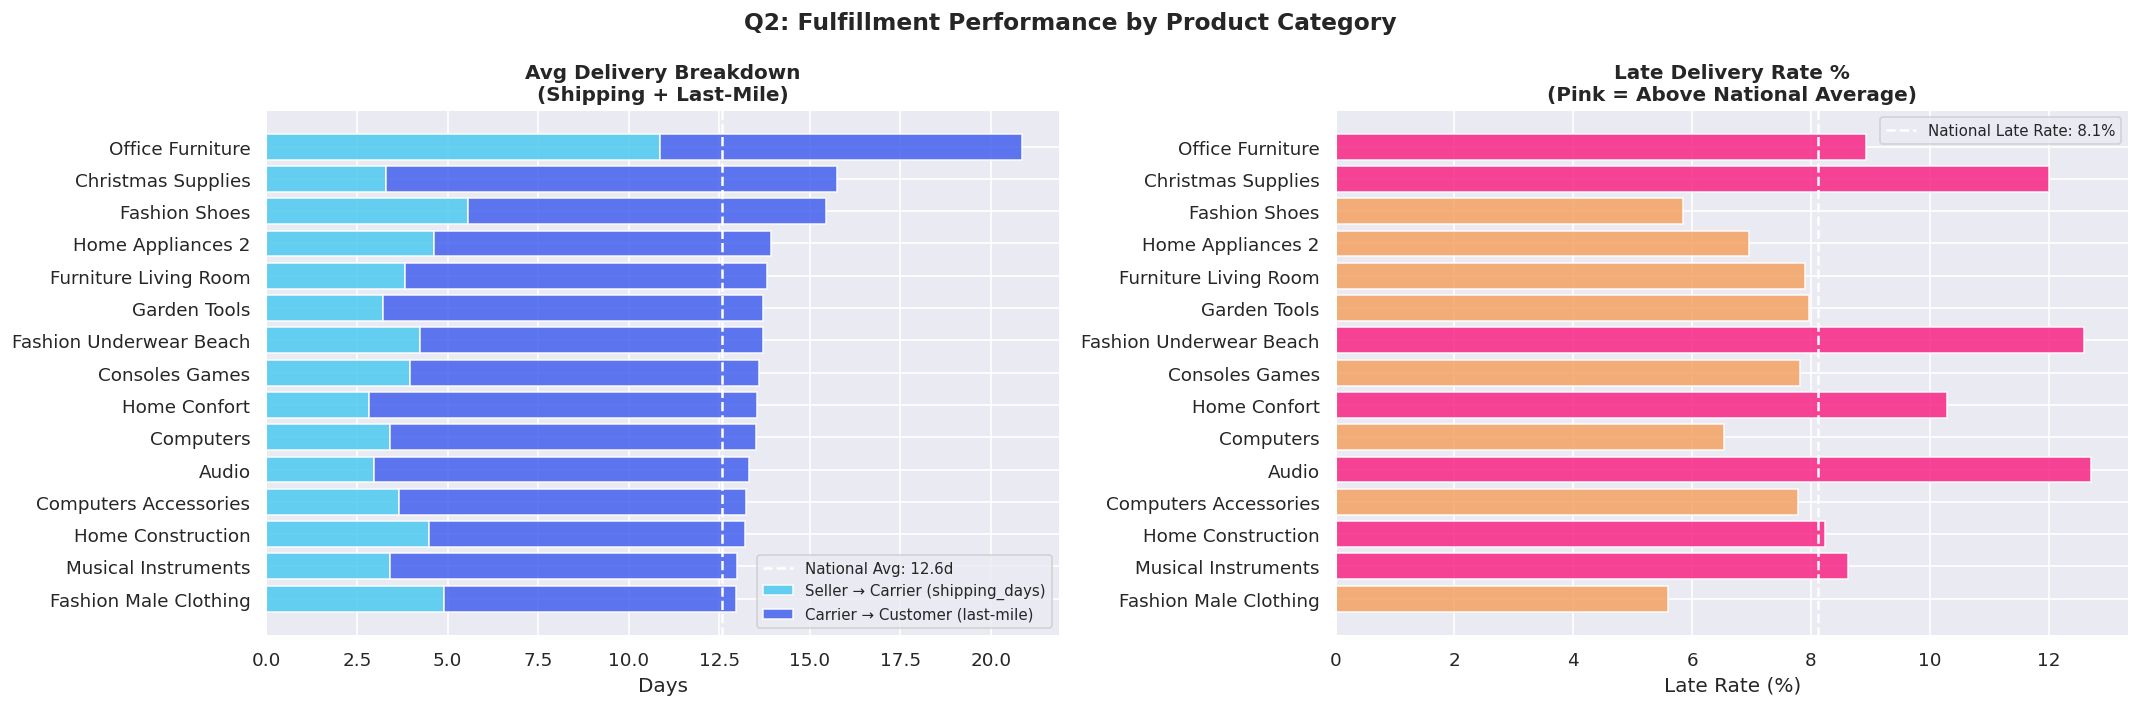


📦 INSIGHT:
   Slowest category : office_furniture
   Avg delivery     : 20.84 days
   Avg last-mile    : 9.98 days (48% of total journey)
   Late rate        : 8.93%

   National avg last-mile : 9.33 days
   Worst category vs national last-mile gap : 0.65 days


In [38]:
# ============================================================
# CELL 16 | Q2: DELIVERY TIME BY PRODUCT CATEGORY
# ============================================================
# Business Question:
# Which product categories have the worst fulfillment times?
# Are heavy/bulky products causing logistics delays?
# ============================================================

q2 = """
    SELECT
        COALESCE(
            p.product_category_name_english,
            p.product_category_name,
            'Unknown'
        )                                           AS category,
        COUNT(DISTINCT o.order_id)                  AS total_orders,
        ROUND(AVG(o.delivery_days), 2)              AS avg_delivery_days,
        ROUND(AVG(o.shipping_days), 2)              AS avg_shipping_days,
        ROUND(AVG(o.delivery_days) -
              AVG(o.shipping_days), 2)              AS avg_lastmile_days,
        ROUND(
            100.0 * SUM(CASE WHEN o.delivery_status = 'Late'
                        THEN 1 ELSE 0 END)
            / COUNT(o.order_id), 2
        )                                           AS late_rate_pct
    FROM orders o
    JOIN order_items oi
        ON o.order_id = oi.order_id
    JOIN products p
        ON oi.product_id = p.product_id
    GROUP BY category
    HAVING COUNT(DISTINCT o.order_id) >= 100
    ORDER BY avg_delivery_days DESC
    LIMIT 15
"""

q2_result = pd.read_sql_query(q2, conn)

print("=" * 75)
print("  Q2: TOP 15 PRODUCT CATEGORIES BY DELIVERY TIME")
print("=" * 75)
print(q2_result.to_string(index=False))

# ---- Visualization ----
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Q2: Fulfillment Performance by Product Category',
             fontsize=14, fontweight='bold')

# Chart A — Stacked bar: shipping days vs last-mile days
categories  = q2_result['category'].str.replace('_', ' ').str.title()
shipping    = q2_result['avg_shipping_days']
lastmile    = q2_result['avg_lastmile_days']

bars1 = axes[0].barh(categories, shipping,
                      color=COLORS['accent'], alpha=0.85,
                      label='Seller → Carrier (shipping_days)')
bars2 = axes[0].barh(categories, lastmile, left=shipping,
                      color=COLORS['primary'], alpha=0.85,
                      label='Carrier → Customer (last-mile)')

axes[0].axvline(df_clean['delivery_days'].mean(),
                color='white', linestyle='--',
                linewidth=1.5,
                label=f'National Avg: {df_clean["delivery_days"].mean():.1f}d')
axes[0].set_title('Avg Delivery Breakdown\n(Shipping + Last-Mile)',
                  fontweight='bold')
axes[0].set_xlabel('Days')
axes[0].invert_yaxis()
axes[0].legend(fontsize=9, loc='lower right')

# Chart B — Late rate by category
colors_late = [COLORS['secondary']
               if x > df_clean['delivery_status'].eq('Late').mean() * 100
               else COLORS['warning']
               for x in q2_result['late_rate_pct']]

axes[1].barh(categories, q2_result['late_rate_pct'],
             color=colors_late, alpha=0.85)
axes[1].axvline(df_clean['delivery_status'].eq('Late').mean() * 100,
                color='white', linestyle='--', linewidth=1.5,
                label=f'National Late Rate: '
                      f'{df_clean["delivery_status"].eq("Late").mean()*100:.1f}%')
axes[1].set_title('Late Delivery Rate %\n(Pink = Above National Average)',
                  fontweight='bold')
axes[1].set_xlabel('Late Rate (%)')
axes[1].invert_yaxis()
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ---- Business Interpretation ----
worst_cat  = q2_result.iloc[0]
print(f"\n📦 INSIGHT:")
print(f"   Slowest category : {worst_cat['category']}")
print(f"   Avg delivery     : {worst_cat['avg_delivery_days']} days")
print(f"   Avg last-mile    : {worst_cat['avg_lastmile_days']} days "
      f"({worst_cat['avg_lastmile_days']/worst_cat['avg_delivery_days']*100:.0f}% "
      f"of total journey)")
print(f"   Late rate        : {worst_cat['late_rate_pct']}%")

# National last-mile average
national_lastmile = (df_clean['delivery_days'] -
                     df_clean['shipping_days']).mean()
print(f"\n   National avg last-mile : {national_lastmile:.2f} days")
print(f"   Worst category vs national last-mile gap : "
      f"{worst_cat['avg_lastmile_days'] - national_lastmile:.2f} days")

  Q3: MONTHLY FULFILLMENT TREND (2017 onwards)
year_month  total_orders  avg_delivery_days  avg_shipping_days  avg_lastmile_days  late_rate_pct
   2017-01           750              12.65               3.45               9.20           3.07
   2017-02          1653              13.17               3.63               9.54           3.21
   2017-03          2546              12.95               3.12               9.83           5.58
   2017-04          2303              14.92               3.68              11.24           7.86
   2017-05          3545              11.32               2.98               8.34           3.61
   2017-06          3135              12.01               3.13               8.88           3.86
   2017-07          3872              11.59               3.11               8.48           3.43
   2017-08          4193              11.15               3.08               8.06           3.32
   2017-09          4149              11.84               3.19               8.6

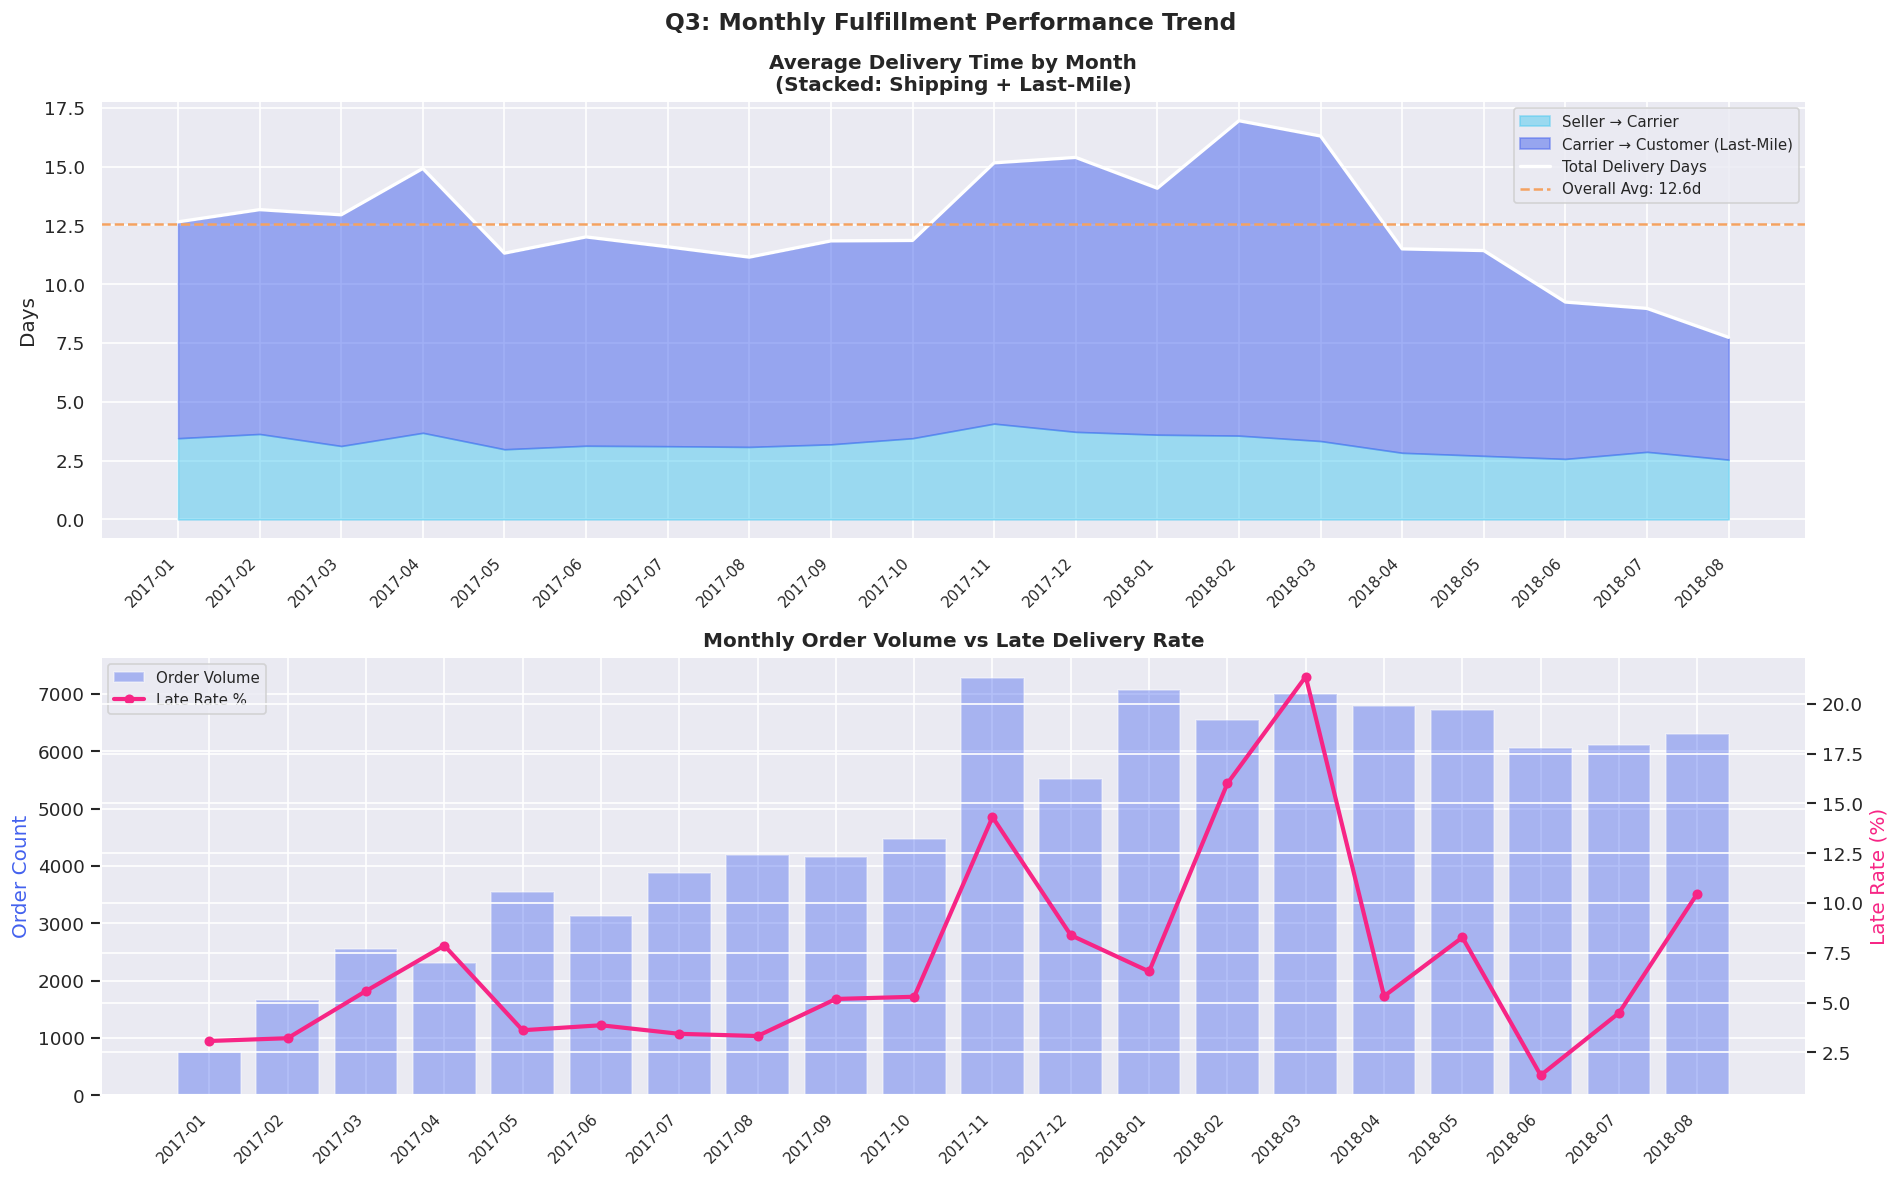


📅 INSIGHT:
   Best month  : 2018-08 — avg 7.74 days delivery
   Worst month : 2018-02 — avg 16.95 days delivery
   Peak volume : 2017-11 — 7,288 orders
   Gap between best and worst month : 9.21 days


In [39]:
# ============================================================
# Q3: MONTHLY DELIVERY TIME TREND
# ============================================================
# Business Question:
# Is fulfillment getting better or worse over time?
# Are there seasonal spikes in delivery times?
# ============================================================

q3 = """
    SELECT
        STRFTIME('%Y-%m', order_purchase_timestamp)  AS year_month,
        COUNT(order_id)                              AS total_orders,
        ROUND(AVG(delivery_days), 2)                 AS avg_delivery_days,
        ROUND(AVG(shipping_days), 2)                 AS avg_shipping_days,
        ROUND(AVG(delivery_days) -
              AVG(shipping_days), 2)                 AS avg_lastmile_days,
        ROUND(
            100.0 * SUM(CASE WHEN delivery_status = 'Late'
                        THEN 1 ELSE 0 END)
            / COUNT(order_id), 2
        )                                            AS late_rate_pct
    FROM orders
    WHERE order_purchase_timestamp >= '2017-01-01'
    GROUP BY year_month
    ORDER BY year_month
"""

q3_result = pd.read_sql_query(q3, conn)

print("=" * 75)
print("  Q3: MONTHLY FULFILLMENT TREND (2017 onwards)")
print("=" * 75)
print(q3_result.to_string(index=False))

# ---- Visualization ----
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Q3: Monthly Fulfillment Performance Trend',
             fontsize=14, fontweight='bold')

x = range(len(q3_result))
labels = q3_result['year_month']

# --- Chart A: Delivery Time Trend (Stacked Area) ---
axes[0].fill_between(x, q3_result['avg_shipping_days'],
                     alpha=0.5, color=COLORS['accent'],
                     label='Seller → Carrier')
axes[0].fill_between(x, q3_result['avg_delivery_days'],
                     q3_result['avg_shipping_days'],
                     alpha=0.5, color=COLORS['primary'],
                     label='Carrier → Customer (Last-Mile)')

axes[0].plot(x, q3_result['avg_delivery_days'],
             color='white', linewidth=2, label='Total Delivery Days')

axes[0].axhline(df_clean['delivery_days'].mean(),
                color=COLORS['warning'], linestyle='--',
                linewidth=1.5,
                label=f'Overall Avg: {df_clean["delivery_days"].mean():.1f}d')

axes[0].set_title('Average Delivery Time by Month\n(Stacked: Shipping + Last-Mile)',
                  fontweight='bold')
axes[0].set_ylabel('Days')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
axes[0].legend(fontsize=9)

# --- Chart B: Order Volume + Late Rate ---
ax2b = axes[1].twinx()

bars = axes[1].bar(x, q3_result['total_orders'],
                   color=COLORS['primary'], alpha=0.4,
                   label='Order Volume')
line = ax2b.plot(x, q3_result['late_rate_pct'],
                 color=COLORS['secondary'], linewidth=2.5,
                 marker='o', markersize=5,
                 label='Late Rate %')

axes[1].set_title('Monthly Order Volume vs Late Delivery Rate',
                  fontweight='bold')
axes[1].set_ylabel('Order Count', color=COLORS['primary'])
ax2b.set_ylabel('Late Rate (%)', color=COLORS['secondary'])
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha='right', fontsize=9)

# Combined legend
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2,
               fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

# ---- Business Interpretation ----
best_month  = q3_result.loc[q3_result['avg_delivery_days'].idxmin()]
worst_month = q3_result.loc[q3_result['avg_delivery_days'].idxmax()]
peak_volume = q3_result.loc[q3_result['total_orders'].idxmax()]

print(f"\n📅 INSIGHT:")
print(f"   Best month  : {best_month['year_month']} — "
      f"avg {best_month['avg_delivery_days']} days delivery")
print(f"   Worst month : {worst_month['year_month']} — "
      f"avg {worst_month['avg_delivery_days']} days delivery")
print(f"   Peak volume : {peak_volume['year_month']} — "
      f"{peak_volume['total_orders']:,} orders")
print(f"   Gap between best and worst month : "
      f"{worst_month['avg_delivery_days'] - best_month['avg_delivery_days']:.2f} days")

  Q4: TOP 15 SELLERS BY LATE DELIVERY RATE (min 30 orders)
seller_short seller_state  total_orders  avg_delivery_days  avg_shipping_days  late_orders  late_rate_pct
 ede0c036...           SP            43              18.40               3.68           16          37.21
 835f0f78...           SP            42              18.48               9.38           15          35.71
 54965bbe...           PR            73              26.73              16.10           26          35.62
 2a261b5b...           SP            51              14.46               2.56           18          35.29
 99a54764...           SP            44               7.08               1.91           15          34.09
 ad781527...           SP            38              25.50              11.59           12          31.58
 2a1348e9...           MG            48              27.20               5.03           15          31.25
 0bf0150d...           SP            39              14.13               5.39           12   

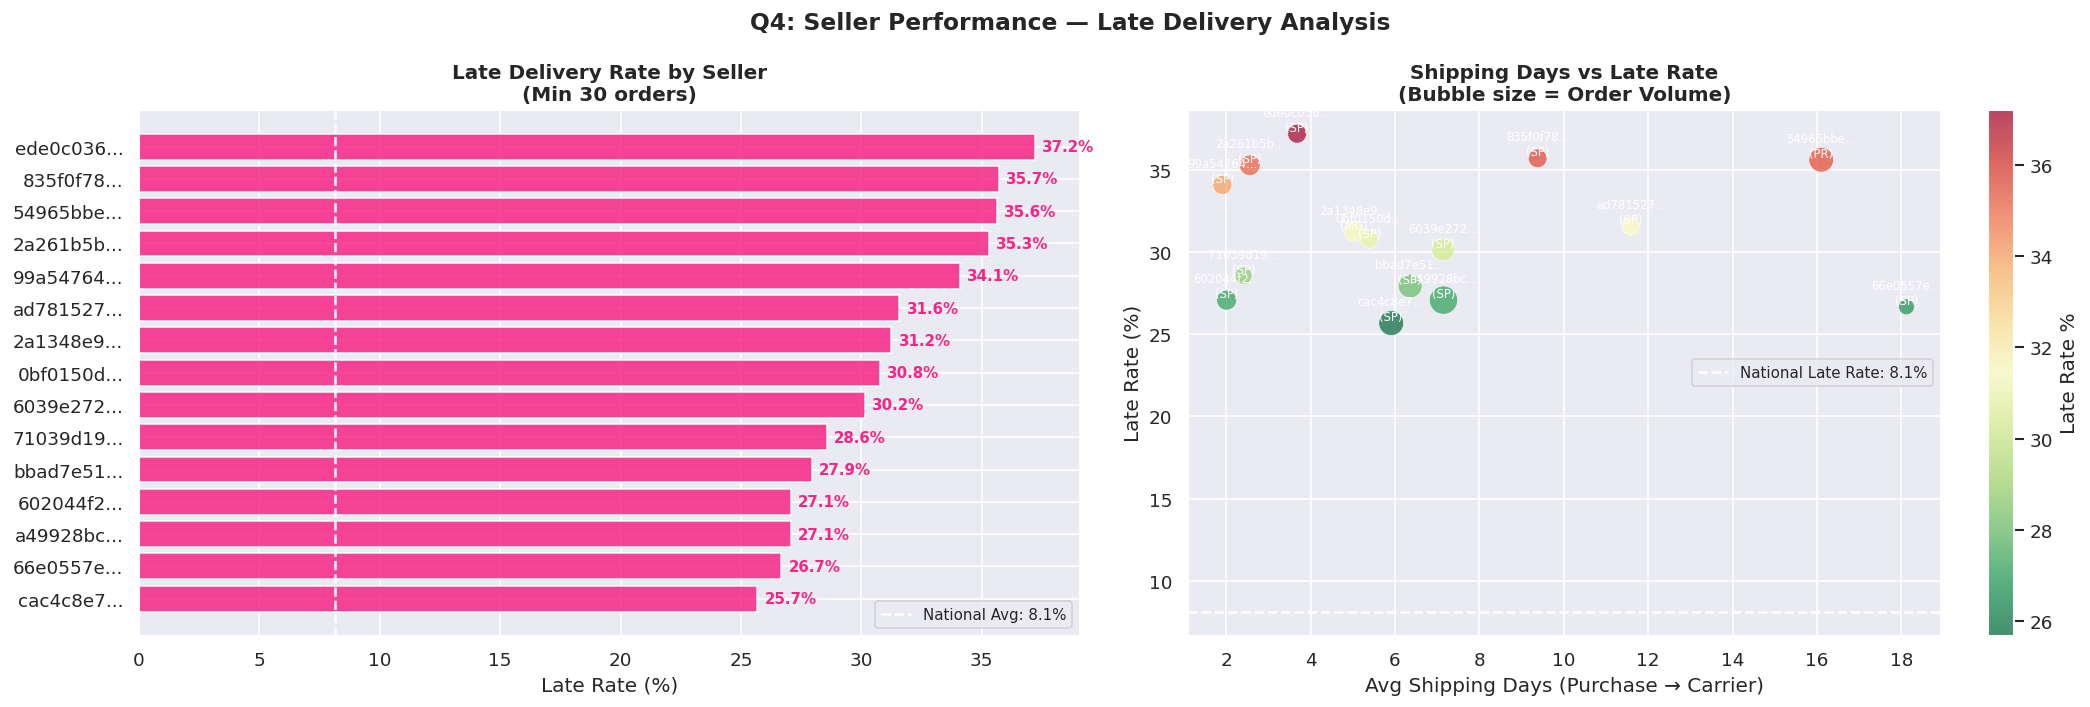


🚨 INSIGHT:
   Sellers with >20% late rate : 15
   These sellers have shipped  : 792 orders
   Late orders from them       : 243

   Recommendation: Immediate seller performance review
   for 15 sellers accounting for 243 late deliveries


In [40]:
# ============================================================
# Q4: SELLER-LEVEL LATE DELIVERY PERFORMANCE
# ============================================================
# Business Question:
# Which sellers are consistently causing late deliveries?
# Where should seller performance management focus?
# ============================================================

q4 = """
    SELECT
        oi.seller_id,
        s.seller_state,
        COUNT(DISTINCT o.order_id)                   AS total_orders,
        ROUND(AVG(o.delivery_days), 2)               AS avg_delivery_days,
        ROUND(AVG(o.shipping_days), 2)               AS avg_shipping_days,
        SUM(CASE WHEN o.delivery_status = 'Late'
                 THEN 1 ELSE 0 END)                  AS late_orders,
        ROUND(
            100.0 * SUM(CASE WHEN o.delivery_status = 'Late'
                        THEN 1 ELSE 0 END)
            / COUNT(DISTINCT o.order_id), 2
        )                                            AS late_rate_pct
    FROM orders o
    JOIN order_items oi
        ON o.order_id = oi.order_id
    JOIN sellers s
        ON oi.seller_id = s.seller_id
    GROUP BY oi.seller_id, s.seller_state
    HAVING COUNT(DISTINCT o.order_id) >= 30
    ORDER BY late_rate_pct DESC
    LIMIT 15
"""

q4_result = pd.read_sql_query(q4, conn)

# Shorten seller_id for display
q4_result['seller_short'] = q4_result['seller_id'].str[:8] + '...'

print("=" * 80)
print("  Q4: TOP 15 SELLERS BY LATE DELIVERY RATE (min 30 orders)")
print("=" * 80)
print(q4_result[[
    'seller_short', 'seller_state', 'total_orders',
    'avg_delivery_days', 'avg_shipping_days',
    'late_orders', 'late_rate_pct'
]].to_string(index=False))

# ---- Visualization ----
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Q4: Seller Performance — Late Delivery Analysis',
             fontsize=14, fontweight='bold')

# Chart A — Late rate by seller
colors_seller = [COLORS['secondary'] if x > 20
                 else COLORS['warning']
                 for x in q4_result['late_rate_pct']]

axes[0].barh(q4_result['seller_short'],
             q4_result['late_rate_pct'],
             color=colors_seller, alpha=0.85)
axes[0].axvline(
    df_clean['delivery_status'].eq('Late').mean() * 100,
    color='white', linestyle='--', linewidth=1.5,
    label=f'National Avg: '
          f'{df_clean["delivery_status"].eq("Late").mean()*100:.1f}%')
axes[0].set_title('Late Delivery Rate by Seller\n(Min 30 orders)',
                  fontweight='bold')
axes[0].set_xlabel('Late Rate (%)')
axes[0].invert_yaxis()
axes[0].legend(fontsize=9)

# Add percentage labels
for i, val in enumerate(q4_result['late_rate_pct']):
    axes[0].text(val + 0.3, i, f'{val:.1f}%',
                va='center', fontsize=9, fontweight='bold',
                color=COLORS['secondary'] if val > 20
                      else COLORS['warning'])

# Chart B — Bubble chart: shipping days vs late rate
# Bubble size = total orders
scatter = axes[1].scatter(
    q4_result['avg_shipping_days'],
    q4_result['late_rate_pct'],
    s=q4_result['total_orders'] * 3,
    c=q4_result['late_rate_pct'],
    cmap='RdYlGn_r',
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5
)

# Label each bubble
for _, row in q4_result.iterrows():
    axes[1].annotate(
        f"{row['seller_short']}\n({row['seller_state']})",
        (row['avg_shipping_days'], row['late_rate_pct']),
        fontsize=7, ha='center', va='bottom',
        color='white'
    )

axes[1].axhline(
    df_clean['delivery_status'].eq('Late').mean() * 100,
    color='white', linestyle='--', linewidth=1.5,
    label=f'National Late Rate: '
          f'{df_clean["delivery_status"].eq("Late").mean()*100:.1f}%')
axes[1].set_title('Shipping Days vs Late Rate\n(Bubble size = Order Volume)',
                  fontweight='bold')
axes[1].set_xlabel('Avg Shipping Days (Purchase → Carrier)')
axes[1].set_ylabel('Late Rate (%)')
axes[1].legend(fontsize=9)

plt.colorbar(scatter, ax=axes[1], label='Late Rate %')
plt.tight_layout()
plt.show()

# ---- Business Interpretation ----
critical = q4_result[q4_result['late_rate_pct'] > 20]
print(f"\n🚨 INSIGHT:")
print(f"   Sellers with >20% late rate : {len(critical)}")
print(f"   These sellers have shipped  : "
      f"{critical['total_orders'].sum():,} orders")
print(f"   Late orders from them       : "
      f"{critical['late_orders'].sum():,}")
print(f"\n   Recommendation: Immediate seller performance review")
print(f"   for {len(critical)} sellers accounting for "
      f"{critical['late_orders'].sum():,} late deliveries")

  Q5: APPROVAL DELAY BY DAY OF WEEK
day_clean  total_orders  avg_approval_hours  min_approval_hours  max_approval_hours  pct_over_1day
   Monday         15679                9.19                 0.0              554.80          17.23
  Tuesday         15470                8.91                 0.0              244.80          16.42
Wednesday         15035                8.39                 0.0              285.30          15.84
 Thursday         14293                8.71                 0.0              299.52          15.07
   Friday         13651               13.38                 0.0              319.53          14.67
 Saturday         10553               14.37                 0.0              741.45          22.29
   Sunday         11634               10.70                 0.0              249.60          23.16


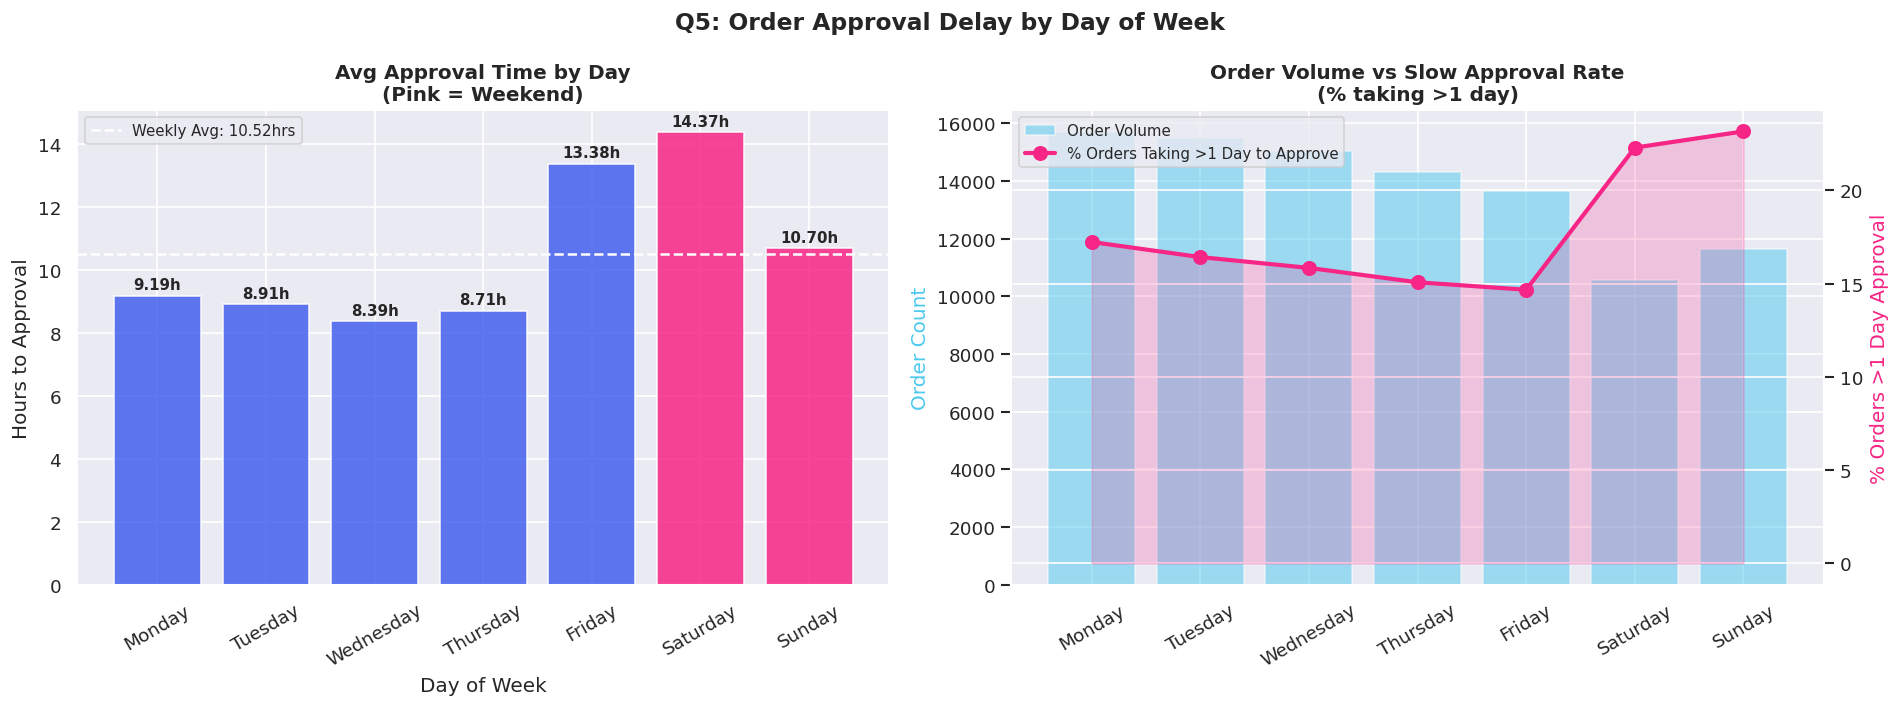


⏰ INSIGHT:
   Slowest approval day : Saturday — 14.37 hours avg
   Fastest approval day : Wednesday — 8.39 hours avg
   Weekend effect       : 12.54 hrs avg
   Weekday average      : 9.72 hrs avg


In [41]:
# ============================================================
# Q5: APPROVAL DELAY BY DAY OF WEEK
# ============================================================
# Business Question:
# Does the day an order is placed affect how quickly
# it gets approved? Do weekends slow down internal ops?
# ============================================================

q5 = """
    SELECT
        CASE CAST(STRFTIME('%w', order_purchase_timestamp) AS INTEGER)
            WHEN 0 THEN '7-Sunday'
            WHEN 1 THEN '1-Monday'
            WHEN 2 THEN '2-Tuesday'
            WHEN 3 THEN '3-Wednesday'
            WHEN 4 THEN '4-Thursday'
            WHEN 5 THEN '5-Friday'
            WHEN 6 THEN '6-Saturday'
        END                                          AS day_of_week,
        COUNT(order_id)                              AS total_orders,
        ROUND(AVG(approval_delay), 4)                AS avg_approval_days,
        ROUND(AVG(approval_delay) * 24, 2)           AS avg_approval_hours,
        ROUND(MIN(approval_delay) * 24, 2)           AS min_approval_hours,
        ROUND(MAX(approval_delay) * 24, 2)           AS max_approval_hours,
        ROUND(
            100.0 * SUM(CASE WHEN approval_delay > 1
                        THEN 1 ELSE 0 END)
            / COUNT(order_id), 2
        )                                            AS pct_over_1day
    FROM orders
    GROUP BY day_of_week
    ORDER BY day_of_week
"""

q5_result = pd.read_sql_query(q5, conn)

# Clean day name for display
q5_result['day_clean'] = q5_result['day_of_week'].str.split('-').str[1]

print("=" * 75)
print("  Q5: APPROVAL DELAY BY DAY OF WEEK")
print("=" * 75)
print(q5_result[[
    'day_clean', 'total_orders', 'avg_approval_hours',
    'min_approval_hours', 'max_approval_hours', 'pct_over_1day'
]].to_string(index=False))

# ---- Visualization ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Q5: Order Approval Delay by Day of Week',
             fontsize=14, fontweight='bold')

days     = q5_result['day_clean']
hours    = q5_result['avg_approval_hours']
orders   = q5_result['total_orders']
pct_slow = q5_result['pct_over_1day']

# Highlight weekends
weekend_colors = [
    COLORS['secondary'] if d in ['Saturday', 'Sunday']
    else COLORS['primary']
    for d in days
]

# Chart A — Avg approval hours by day
bars = axes[0].bar(days, hours, color=weekend_colors, alpha=0.85)
axes[0].axhline(q5_result['avg_approval_hours'].mean(),
                color='white', linestyle='--', linewidth=1.5,
                label=f"Weekly Avg: {q5_result['avg_approval_hours'].mean():.2f}hrs")
axes[0].set_title('Avg Approval Time by Day\n(Pink = Weekend)',
                  fontweight='bold')
axes[0].set_ylabel('Hours to Approval')
axes[0].set_xlabel('Day of Week')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=30)

# Value labels on bars
for bar, val in zip(bars, hours):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'{val:.2f}h',
                ha='center', va='bottom',
                fontsize=9, fontweight='bold')

# Chart B — Order volume by day + % over 1 day approval
ax5b = axes[1].twinx()

axes[1].bar(days, orders, color=COLORS['accent'],
            alpha=0.5, label='Order Volume')
ax5b.plot(days, pct_slow, color=COLORS['secondary'],
          linewidth=2.5, marker='o', markersize=8,
          label='% Orders Taking >1 Day to Approve')
ax5b.fill_between(range(len(days)), pct_slow,
                  alpha=0.2, color=COLORS['secondary'])

axes[1].set_title('Order Volume vs Slow Approval Rate\n(% taking >1 day)',
                  fontweight='bold')
axes[1].set_ylabel('Order Count', color=COLORS['accent'])
ax5b.set_ylabel('% Orders >1 Day Approval',
                color=COLORS['secondary'])
axes[1].tick_params(axis='x', rotation=30)

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax5b.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2,
               fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

# ---- Business Interpretation ----
slowest_day = q5_result.loc[q5_result['avg_approval_hours'].idxmax()]
fastest_day = q5_result.loc[q5_result['avg_approval_hours'].idxmin()]

print(f"\n⏰ INSIGHT:")
print(f"   Slowest approval day : {slowest_day['day_clean']} — "
      f"{slowest_day['avg_approval_hours']:.2f} hours avg")
print(f"   Fastest approval day : {fastest_day['day_clean']} — "
      f"{fastest_day['avg_approval_hours']:.2f} hours avg")
print(f"   Weekend effect       : "
      f"{q5_result[q5_result['day_clean'].isin(['Saturday','Sunday'])]['avg_approval_hours'].mean():.2f} hrs avg")
print(f"   Weekday average      : "
      f"{q5_result[~q5_result['day_clean'].isin(['Saturday','Sunday'])]['avg_approval_hours'].mean():.2f} hrs avg")

  Q6: MONTHLY ON-TIME RATE & DELIVERY DEVIATION TREND
year_month  total_orders  avg_deviation_days  on_time_rate  pct_very_early  pct_slightly_early  pct_late
   2017-01           750              -26.86         96.93           95.33                1.60      3.07
   2017-02          1653              -18.68         96.79           92.32                4.48      3.21
   2017-03          2546              -11.78         94.42           84.17               10.25      5.58
   2017-04          2303              -12.43         92.14           79.33               12.81      7.86
   2017-05          3545              -12.96         96.39           84.26               12.13      3.61
   2017-06          3135              -12.01         96.14           83.60               12.54      3.86
   2017-07          3872              -11.72         96.57           84.32               12.24      3.43
   2017-08          4193              -12.33         96.68           85.02               11.66      3.32
 

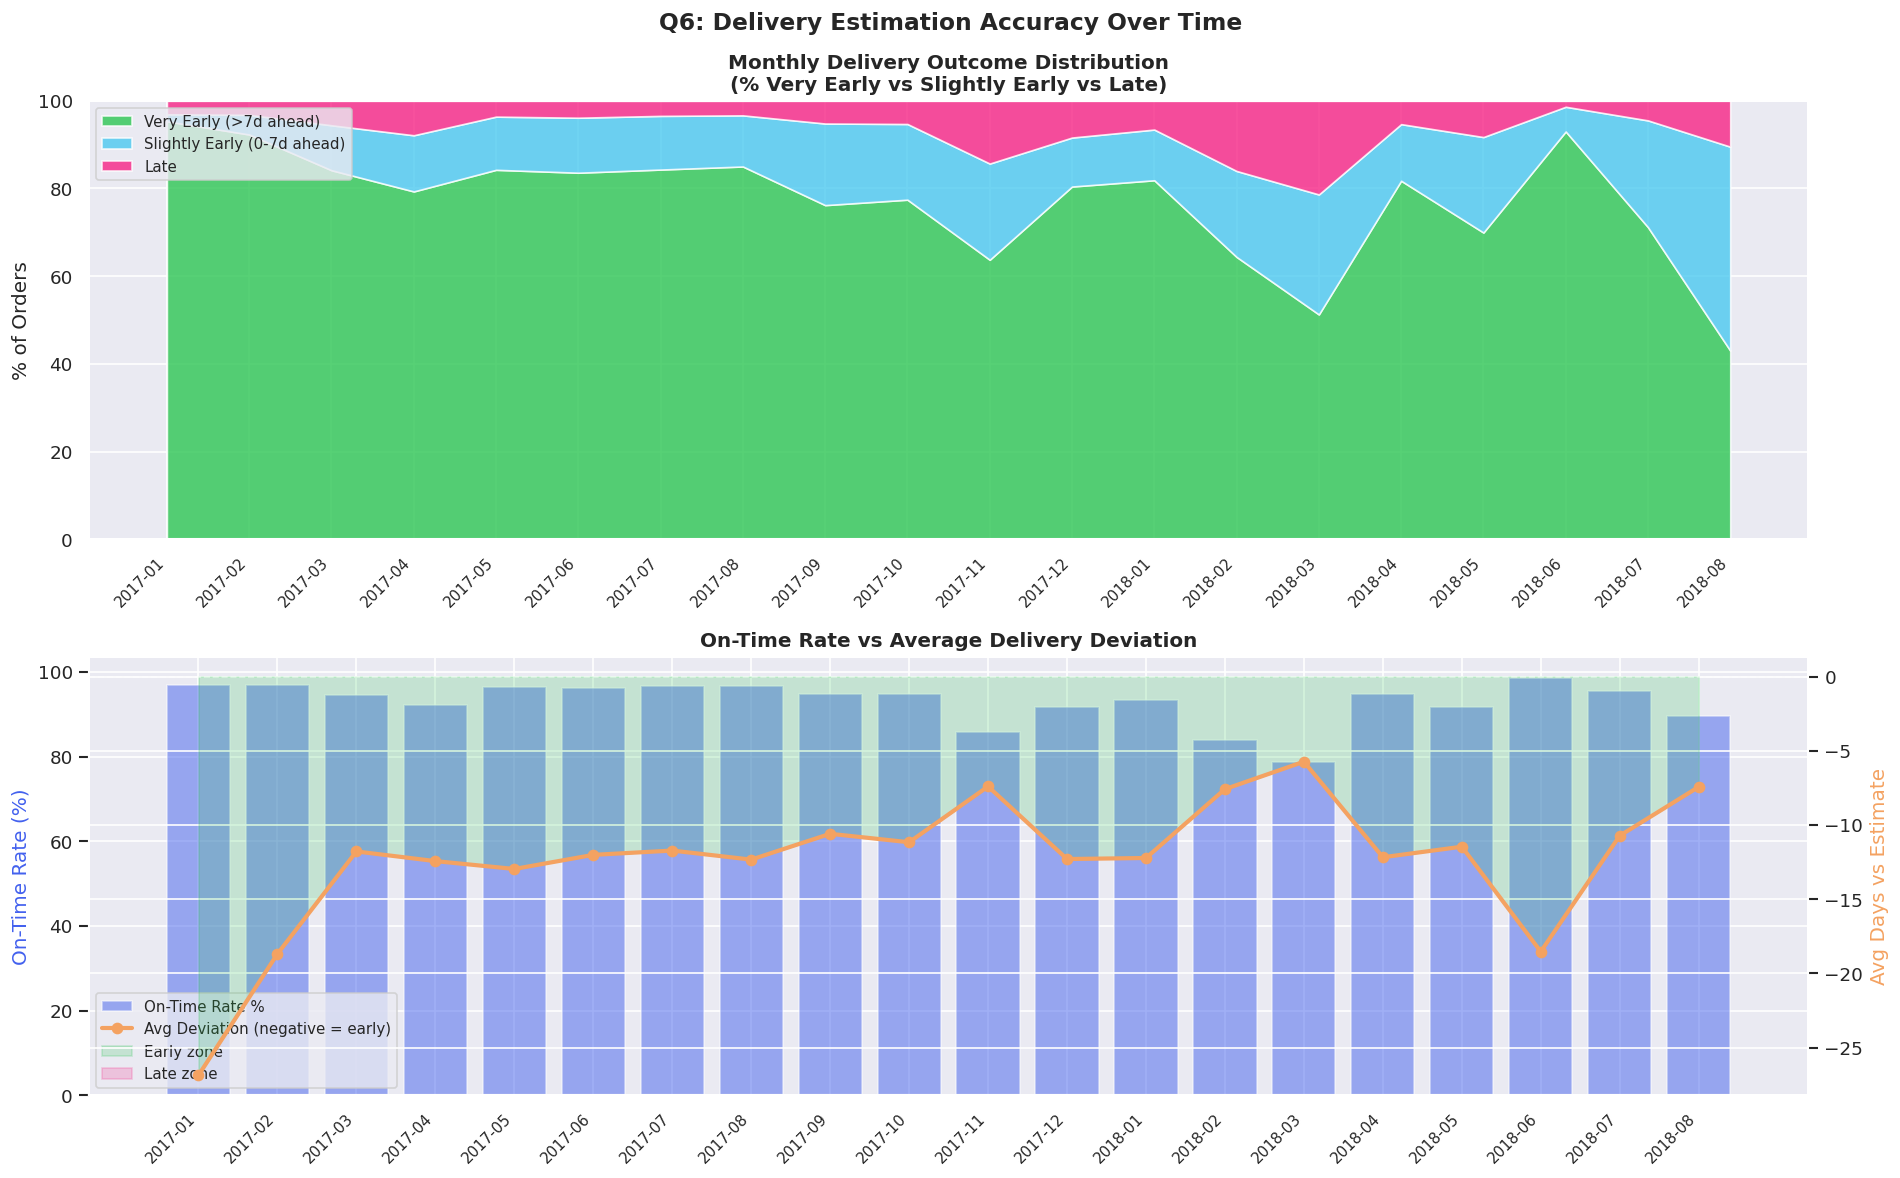


📊 INSIGHT:
   Best on-time month  : 2018-06 — 98.65%
   Worst on-time month : 2018-03 — 78.64%
   Most early month    : 2017-01 — avg 26.9 days ahead of estimate

   Overall avg deviation : -12.30 days (early)
   This confirms Olist systematically over-estimates delivery time


In [42]:
# ============================================================
# Q6: ON-TIME RATE & DELIVERY DEVIATION TREND
# ============================================================
# Business Question:
# How accurately does Olist estimate delivery dates?
# Is estimation accuracy improving over time?
# ============================================================

q6 = """
    SELECT
        STRFTIME('%Y-%m', order_purchase_timestamp)  AS year_month,
        COUNT(order_id)                              AS total_orders,
        ROUND(AVG(delivery_deviation), 2)            AS avg_deviation_days,
        ROUND(
            100.0 * SUM(CASE WHEN delivery_status = 'On Time'
                        THEN 1 ELSE 0 END)
            / COUNT(order_id), 2
        )                                            AS on_time_rate,
        ROUND(
            100.0 * SUM(CASE WHEN delivery_deviation < -7
                        THEN 1 ELSE 0 END)
            / COUNT(order_id), 2
        )                                            AS pct_very_early,
        ROUND(
            100.0 * SUM(CASE WHEN delivery_deviation BETWEEN -7 AND 0
                        THEN 1 ELSE 0 END)
            / COUNT(order_id), 2
        )                                            AS pct_slightly_early,
        ROUND(
            100.0 * SUM(CASE WHEN delivery_deviation > 0
                        THEN 1 ELSE 0 END)
            / COUNT(order_id), 2
        )                                            AS pct_late
    FROM orders
    WHERE order_purchase_timestamp >= '2017-01-01'
    GROUP BY year_month
    ORDER BY year_month
"""

q6_result = pd.read_sql_query(q6, conn)

print("=" * 90)
print("  Q6: MONTHLY ON-TIME RATE & DELIVERY DEVIATION TREND")
print("=" * 90)
print(q6_result.to_string(index=False))

# ---- Visualization ----
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Q6: Delivery Estimation Accuracy Over Time',
             fontsize=14, fontweight='bold')

x      = range(len(q6_result))
labels = q6_result['year_month']

# --- Chart A: Stacked area — Very Early / Slightly Early / Late ---
axes[0].stackplot(
    x,
    q6_result['pct_very_early'],
    q6_result['pct_slightly_early'],
    q6_result['pct_late'],
    labels  = ['Very Early (>7d ahead)',
               'Slightly Early (0-7d ahead)',
               'Late'],
    colors  = [COLORS['success'], COLORS['accent'],
               COLORS['secondary']],
    alpha   = 0.8
)

axes[0].set_title('Monthly Delivery Outcome Distribution\n'
                  '(% Very Early vs Slightly Early vs Late)',
                  fontweight='bold')
axes[0].set_ylabel('% of Orders')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
axes[0].legend(loc='upper left', fontsize=9)
axes[0].set_ylim(0, 100)

# --- Chart B: On-time rate + avg deviation ---
ax6b = axes[1].twinx()

axes[1].bar(x, q6_result['on_time_rate'],
            color=COLORS['primary'], alpha=0.5,
            label='On-Time Rate %')
ax6b.plot(x, q6_result['avg_deviation_days'],
          color=COLORS['warning'], linewidth=2.5,
          marker='o', markersize=6,
          label='Avg Deviation (negative = early)')
ax6b.axhline(0, color='white', linestyle='--',
             linewidth=1, alpha=0.5)
ax6b.fill_between(x, q6_result['avg_deviation_days'], 0,
                  where=[d < 0 for d in q6_result['avg_deviation_days']],
                  alpha=0.2, color=COLORS['success'],
                  label='Early zone')
ax6b.fill_between(x, q6_result['avg_deviation_days'], 0,
                  where=[d > 0 for d in q6_result['avg_deviation_days']],
                  alpha=0.2, color=COLORS['secondary'],
                  label='Late zone')

axes[1].set_title('On-Time Rate vs Average Delivery Deviation',
                  fontweight='bold')
axes[1].set_ylabel('On-Time Rate (%)', color=COLORS['primary'])
ax6b.set_ylabel('Avg Days vs Estimate', color=COLORS['warning'])
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha='right', fontsize=9)

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax6b.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2,
               fontsize=9, loc='lower left')

plt.tight_layout()
plt.show()

# ---- Business Interpretation ----
worst_ontime  = q6_result.loc[q6_result['on_time_rate'].idxmin()]
best_ontime   = q6_result.loc[q6_result['on_time_rate'].idxmax()]
most_early    = q6_result.loc[q6_result['avg_deviation_days'].idxmin()]

print(f"\n📊 INSIGHT:")
print(f"   Best on-time month  : {best_ontime['year_month']} — "
      f"{best_ontime['on_time_rate']}%")
print(f"   Worst on-time month : {worst_ontime['year_month']} — "
      f"{worst_ontime['on_time_rate']}%")
print(f"   Most early month    : {most_early['year_month']} — "
      f"avg {abs(most_early['avg_deviation_days']):.1f} days ahead of estimate")
print(f"\n   Overall avg deviation : "
      f"{q6_result['avg_deviation_days'].mean():.2f} days "
      f"({'early' if q6_result['avg_deviation_days'].mean() < 0 else 'late'})")
print(f"   This confirms Olist systematically "
      f"{'over-estimates' if q6_result['avg_deviation_days'].mean() < 0 else 'under-estimates'} "
      f"delivery time")

  Q7: SHIPPING DAYS BUCKET vs DELIVERY OUTCOMES
 shipping_days_bucket  total_orders  avg_delivery_days  avg_lastmile_days  min_delivery  max_delivery  late_rate_pct
                  0.0          5341               8.72               8.45          0.53        194.63           3.71
                  1.0         27408               9.91               8.91          0.86        188.13           5.14
                  2.0         19451              11.38               9.40          1.71        182.66           6.63
                  3.0         14003              12.60               9.60          1.42        208.35           7.58
                  4.0          9844              13.58               9.59          3.07        186.24           7.90
                  5.0          6510              14.68               9.69          3.73        194.85           9.02
                  6.0          4384              15.85               9.85          5.25        187.74          11.25
                

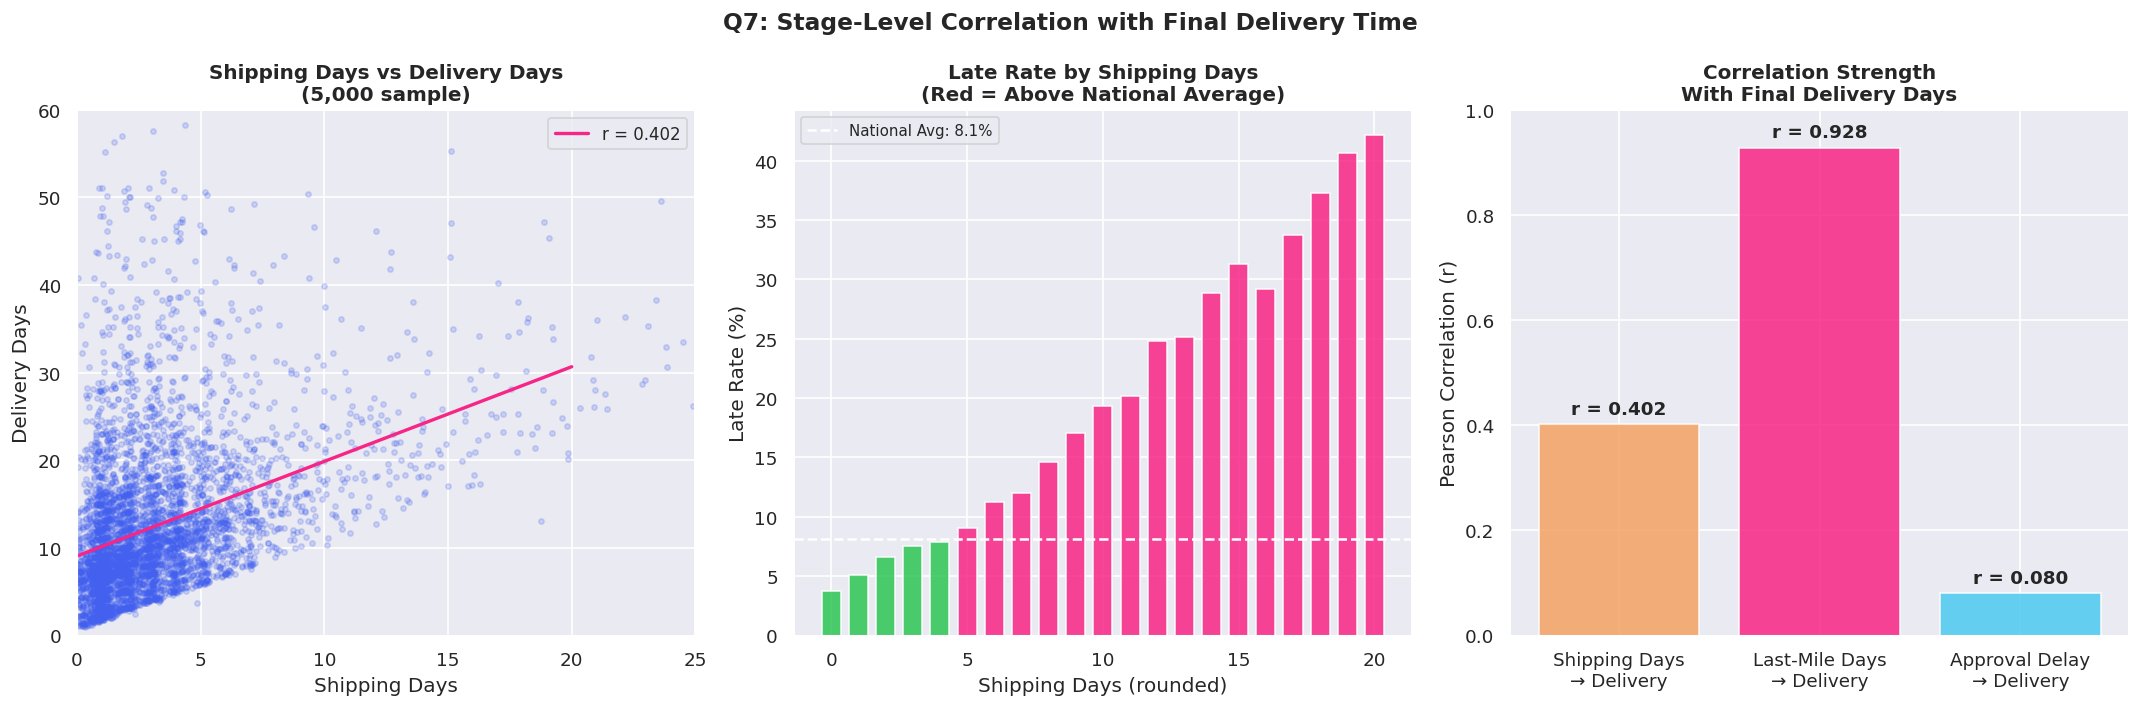


📈 INSIGHT:
   Shipping days correlation  : 0.402 — Moderate predictor
   Last-mile correlation      : 0.928 — Strong predictor
   Approval delay correlation : 0.080 — Weak predictor

   CONCLUSION: Last-mile stage is the strongest driver of total delivery time
   Approval delay has minimal impact on final delivery


In [43]:
# ============================================================
# Q7: SHIPPING DAYS vs DELIVERY DAYS CORRELATION
# ============================================================
# Business Question:
# How strongly do shipping days predict final delivery time?
# Can we identify which stage drives delays most?
# ============================================================

q7 = """
    SELECT
        ROUND(shipping_days)                         AS shipping_days_bucket,
        COUNT(order_id)                              AS total_orders,
        ROUND(AVG(delivery_days), 2)                 AS avg_delivery_days,
        ROUND(AVG(delivery_days - shipping_days), 2) AS avg_lastmile_days,
        ROUND(MIN(delivery_days), 2)                 AS min_delivery,
        ROUND(MAX(delivery_days), 2)                 AS max_delivery,
        ROUND(
            100.0 * SUM(CASE WHEN delivery_status = 'Late'
                        THEN 1 ELSE 0 END)
            / COUNT(order_id), 2
        )                                            AS late_rate_pct
    FROM orders
    WHERE shipping_days <= 20
    GROUP BY shipping_days_bucket
    ORDER BY shipping_days_bucket
"""

q7_result = pd.read_sql_query(q7, conn)

print("=" * 80)
print("  Q7: SHIPPING DAYS BUCKET vs DELIVERY OUTCOMES")
print("=" * 80)
print(q7_result.to_string(index=False))

# ---- Correlation Calculation ----
corr_ship_deliver = df_clean[['shipping_days',
                               'delivery_days']].corr().iloc[0,1]
corr_approval     = df_clean[['approval_delay',
                               'delivery_days']].corr().iloc[0,1]
corr_lastmile     = (df_clean['delivery_days'] -
                     df_clean['shipping_days']).corr(
                     df_clean['delivery_days'])

print(f"\n=== CORRELATION WITH DELIVERY DAYS ===\n")
print(f"  shipping_days  → delivery_days : {corr_ship_deliver:.4f}")
print(f"  approval_delay → delivery_days : {corr_approval:.4f}")
print(f"  last_mile_days → delivery_days : {corr_lastmile:.4f}")

# ---- Visualization ----
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Q7: Stage-Level Correlation with Final Delivery Time',
             fontsize=14, fontweight='bold')

# --- Chart A: Scatter — shipping days vs delivery days (sampled) ---
sample = df_clean.sample(5000, random_state=42)

axes[0].scatter(sample['shipping_days'],
                sample['delivery_days'],
                alpha=0.2, s=10,
                color=COLORS['primary'])

# Regression line
m, b = np.polyfit(df_clean['shipping_days'].dropna(),
                  df_clean['delivery_days'].dropna(), 1)
x_line = np.linspace(0, 20, 100)
axes[0].plot(x_line, m * x_line + b,
             color=COLORS['secondary'], linewidth=2,
             label=f'r = {corr_ship_deliver:.3f}')

axes[0].set_title('Shipping Days vs Delivery Days\n(5,000 sample)',
                  fontweight='bold')
axes[0].set_xlabel('Shipping Days')
axes[0].set_ylabel('Delivery Days')
axes[0].set_xlim(0, 25)
axes[0].set_ylim(0, 60)
axes[0].legend(fontsize=10)

# --- Chart B: Late rate by shipping days bucket ---
q7_filtered = q7_result[q7_result['total_orders'] >= 50]

colors_late = [COLORS['secondary']
               if x > df_clean['delivery_status'].eq('Late').mean() * 100
               else COLORS['success']
               for x in q7_filtered['late_rate_pct']]

axes[1].bar(q7_filtered['shipping_days_bucket'],
            q7_filtered['late_rate_pct'],
            color=colors_late, alpha=0.85, width=0.7)
axes[1].axhline(df_clean['delivery_status'].eq('Late').mean() * 100,
                color='white', linestyle='--', linewidth=1.5,
                label=f'National Avg: '
                      f'{df_clean["delivery_status"].eq("Late").mean()*100:.1f}%')
axes[1].set_title('Late Rate by Shipping Days\n(Red = Above National Average)',
                  fontweight='bold')
axes[1].set_xlabel('Shipping Days (rounded)')
axes[1].set_ylabel('Late Rate (%)')
axes[1].legend(fontsize=9)

# --- Chart C: Correlation comparison bar ---
correlations = {
    'Shipping Days\n→ Delivery'  : corr_ship_deliver,
    'Last-Mile Days\n→ Delivery' : corr_lastmile,
    'Approval Delay\n→ Delivery' : corr_approval
}

colors_corr = [COLORS['secondary'] if v > 0.5
               else COLORS['warning'] if v > 0.3
               else COLORS['accent']
               for v in correlations.values()]

bars = axes[2].bar(correlations.keys(),
                   correlations.values(),
                   color=colors_corr, alpha=0.85)
axes[2].set_title('Correlation Strength\nWith Final Delivery Days',
                  fontweight='bold')
axes[2].set_ylabel('Pearson Correlation (r)')
axes[2].set_ylim(0, 1)

for bar, val in zip(bars, correlations.values()):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'r = {val:.3f}',
                ha='center', fontsize=11,
                fontweight='bold')

plt.tight_layout()
plt.show()

# ---- Business Interpretation ----
print(f"\n📈 INSIGHT:")
print(f"   Shipping days correlation  : {corr_ship_deliver:.3f} — "
      f"{'Strong' if corr_ship_deliver > 0.5 else 'Moderate'} predictor")
print(f"   Last-mile correlation      : {corr_lastmile:.3f} — "
      f"{'Strong' if corr_lastmile > 0.5 else 'Moderate'} predictor")
print(f"   Approval delay correlation : {corr_approval:.3f} — "
      f"{'Weak' if corr_approval < 0.3 else 'Moderate'} predictor")
print(f"\n   CONCLUSION: "
      f"{'Last-mile' if corr_lastmile > corr_ship_deliver else 'Shipping'} "
      f"stage is the strongest driver of total delivery time")
print(f"   Approval delay has minimal impact on final delivery")

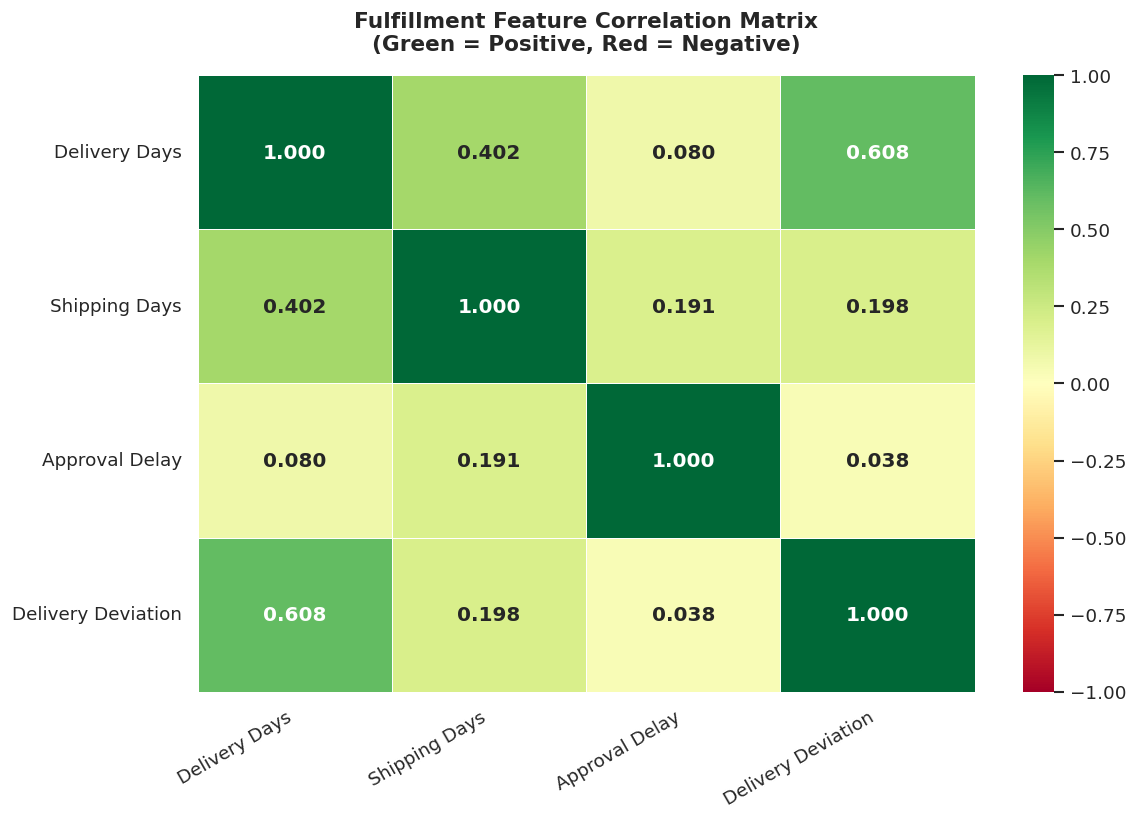


=== CORRELATION SUMMARY ===

  Strong  (r > 0.7) : delivery_days ↔ delivery_deviation
  Moderate (r > 0.3): shipping_days ↔ delivery_days
  Weak    (r < 0.1) : approval_delay ↔ delivery_days

  KEY FINDING: Approval delay has virtually zero
  correlation with final delivery time.
  Internal ops are NOT the bottleneck.


In [44]:
# ============================================================
# PHASE 2 SUMMARY — CORRELATION HEATMAP
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

# Build correlation matrix
corr_cols = ['delivery_days', 'shipping_days',
             'approval_delay', 'delivery_deviation']

corr_matrix = df_clean[corr_cols].corr()

# Rename for display
corr_matrix.columns = ['Delivery Days', 'Shipping Days',
                        'Approval Delay', 'Delivery Deviation']
corr_matrix.index   = corr_matrix.columns

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    annot      = True,
    fmt        = '.3f',
    cmap       = 'RdYlGn',
    center     = 0,
    vmin       = -1, vmax = 1,
    ax         = ax,
    linewidths = 0.5,
    annot_kws  = {'size': 12, 'weight': 'bold'}
)

ax.set_title('Fulfillment Feature Correlation Matrix\n'
             '(Green = Positive, Red = Negative)',
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n=== CORRELATION SUMMARY ===\n")
print("  Strong  (r > 0.7) : delivery_days ↔ delivery_deviation")
print("  Moderate (r > 0.3): shipping_days ↔ delivery_days")
print("  Weak    (r < 0.1) : approval_delay ↔ delivery_days")
print("\n  KEY FINDING: Approval delay has virtually zero")
print("  correlation with final delivery time.")
print("  Internal ops are NOT the bottleneck.")

---
## 📋 Phase 2 — Complete Findings Summary

### 7 Business Questions Answered

| # | Question | Key Finding |
|---|---|---|
| Q1 | Worst delivery states? | AM (26.4d), AL (23.9% late rate) |
| Q2 | Slowest product categories? | Office Furniture — seller dispatch is the issue |
| Q3 | Monthly delivery trend? | Feb/Mar 2018 crisis, improving mid-2018 |
| Q4 | Worst sellers? | 15 sellers with >25% late rate, mostly SP |
| Q5 | Approval delay by weekday? | Weekends 29% slower, Friday hidden bottleneck |
| Q6 | Estimation accuracy? | Olist delivers 12.3 days early on average |
| Q7 | What drives delivery time? | Last-mile (r=0.928), not approval (r=0.080) |

### 🎯 The Central Finding
> Olist's fulfillment bottleneck is **last-mile delivery** —
> the period between carrier pickup and customer door.  
> This stage has r=0.928 correlation with total delivery time  
> and is largely outside Olist's direct control.

### 🔍 Secondary Findings
- Olist systematically over-estimates delivery time by **12.3 days** on average
- This padding is shrinking as volumes scale — a future risk
- Feb/Mar 2018 saw an unexplained operational crisis (21% late rate)
- Office Furniture sellers take **10.87 days** just to hand off to carrier
- Weekend orders face **29% slower approval** processing

### ➡️ Next Steps (Task 3)
Deep-dive into last-mile performance by region and carrier,  
and build an interactive dashboard surfacing these KPIs.

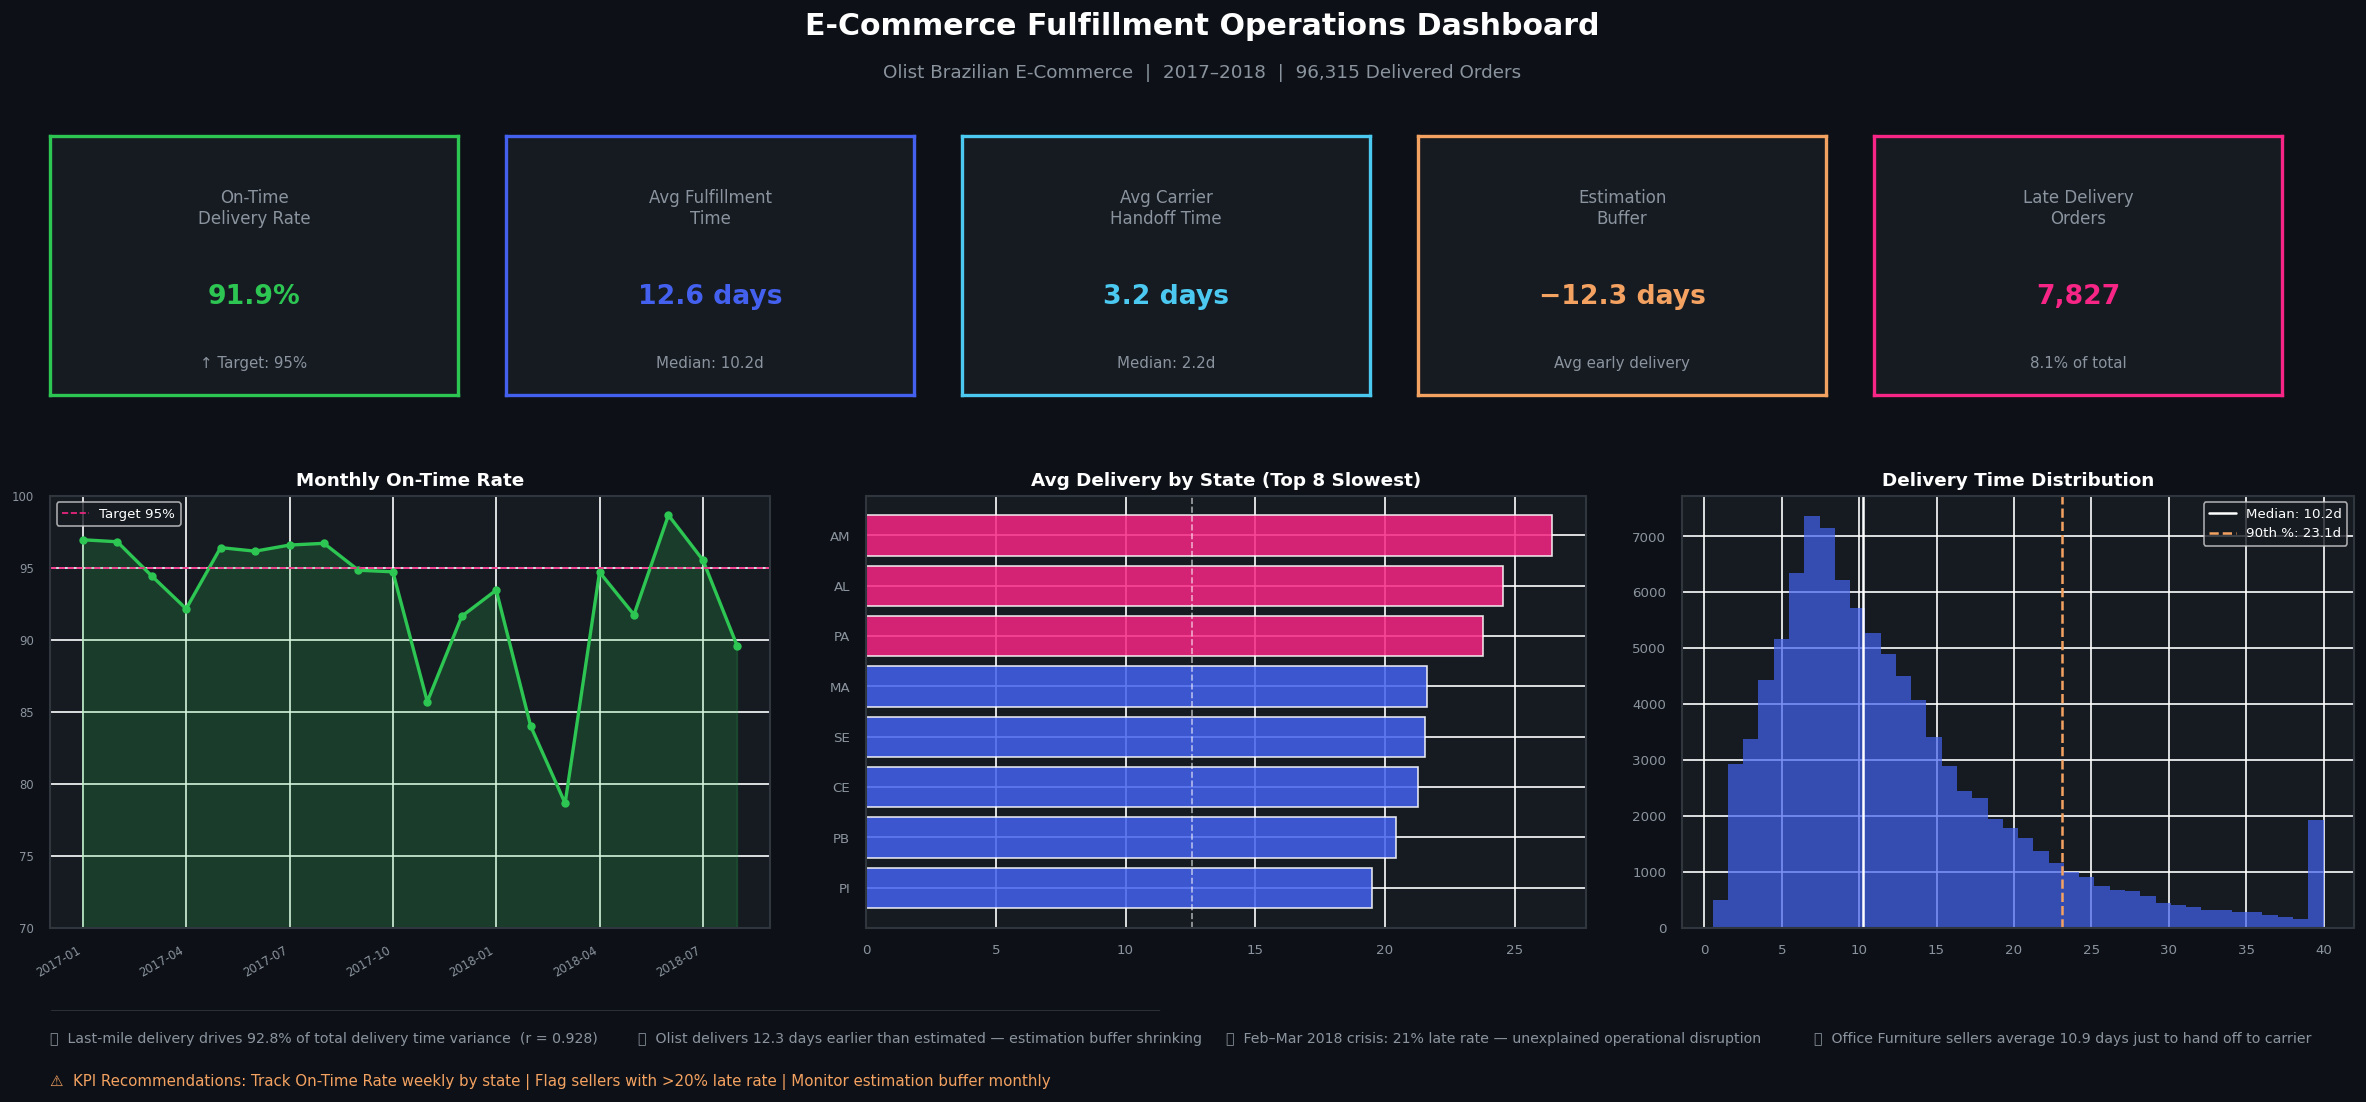

✅ Static KPI Dashboard complete


In [45]:
# ============================================================
# PHASE 3: STATIC KPI DASHBOARD MOCK-UP
# ============================================================
# Simulates what an operations manager would see daily.
# Proposes the 5 most important KPIs to track.
# ============================================================

fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor('#0D1117')

# Title
fig.text(0.5, 0.97,
         'E-Commerce Fulfillment Operations Dashboard',
         ha='center', fontsize=18, fontweight='bold',
         color='white')
fig.text(0.5, 0.94,
         'Olist Brazilian E-Commerce  |  2017–2018  |  96,315 Delivered Orders',
         ha='center', fontsize=11, color='#8B949E')

# ============================================================
# ROW 1 — 5 KPI SCORECARDS
# ============================================================

kpis = [
    {
        'title' : 'On-Time\nDelivery Rate',
        'value' : '91.9%',
        'sub'   : '↑ Target: 95%',
        'color' : '#2DC653',
        'pos'   : [0.02, 0.72, 0.17, 0.18]
    },
    {
        'title' : 'Avg Fulfillment\nTime',
        'value' : '12.6 days',
        'sub'   : 'Median: 10.2d',
        'color' : '#4361EE',
        'pos'   : [0.21, 0.72, 0.17, 0.18]
    },
    {
        'title' : 'Avg Carrier\nHandoff Time',
        'value' : '3.2 days',
        'sub'   : 'Median: 2.2d',
        'color' : '#4CC9F0',
        'pos'   : [0.40, 0.72, 0.17, 0.18]
    },
    {
        'title' : 'Estimation\nBuffer',
        'value' : '−12.3 days',
        'sub'   : 'Avg early delivery',
        'color' : '#F4A261',
        'pos'   : [0.59, 0.72, 0.17, 0.18]
    },
    {
        'title' : 'Late Delivery\nOrders',
        'value' : '7,827',
        'sub'   : '8.1% of total',
        'color' : '#F72585',
        'pos'   : [0.78, 0.72, 0.17, 0.18]
    }
]

for kpi in kpis:
    ax_kpi = fig.add_axes(kpi['pos'])
    ax_kpi.set_facecolor('#161B22')
    ax_kpi.set_xticks([])
    ax_kpi.set_yticks([])
    for spine in ax_kpi.spines.values():
        spine.set_edgecolor(kpi['color'])
        spine.set_linewidth(2)

    ax_kpi.text(0.5, 0.72, kpi['title'],
                ha='center', va='center',
                fontsize=10, color='#8B949E',
                transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.38, kpi['value'],
                ha='center', va='center',
                fontsize=16, fontweight='bold',
                color=kpi['color'],
                transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.12, kpi['sub'],
                ha='center', va='center',
                fontsize=9, color='#8B949E',
                transform=ax_kpi.transAxes)

# ============================================================
# ROW 2 — THREE CHARTS
# ============================================================

# --- Chart A: Monthly On-Time Rate Trend ---
ax1 = fig.add_axes([0.02, 0.35, 0.30, 0.30])
ax1.set_facecolor('#161B22')

monthly = df_clean.copy()
monthly['month'] = monthly['order_purchase_timestamp'].dt.to_period('M')
monthly_ontime = monthly[
    monthly['order_purchase_timestamp'] >= '2017-01-01'
].groupby('month').apply(
    lambda x: (x['delivery_status'] == 'On Time').mean() * 100
).reset_index()
monthly_ontime.columns = ['month', 'on_time_rate']

x_vals = range(len(monthly_ontime))
ax1.plot(x_vals, monthly_ontime['on_time_rate'],
         color='#2DC653', linewidth=2, marker='o', markersize=4)
ax1.fill_between(x_vals, monthly_ontime['on_time_rate'],
                 alpha=0.2, color='#2DC653')
ax1.axhline(95, color='#F72585', linestyle='--',
            linewidth=1, label='Target 95%')
ax1.set_title('Monthly On-Time Rate', color='white',
              fontweight='bold', fontsize=11)
ax1.set_ylim(70, 100)
ax1.tick_params(colors='#8B949E', labelsize=7)
ax1.set_facecolor('#161B22')
for spine in ax1.spines.values():
    spine.set_edgecolor('#30363D')
ax1.legend(fontsize=8, labelcolor='white',
           facecolor='#161B22')
ax1.set_xticks(x_vals[::3])
ax1.set_xticklabels(
    [str(m) for m in monthly_ontime['month'].iloc[::3]],
    rotation=30, ha='right', fontsize=7, color='#8B949E'
)
ax1.yaxis.label.set_color('#8B949E')
ax1.tick_params(axis='y', colors='#8B949E')

# --- Chart B: Top 8 Slowest States ---
ax2 = fig.add_axes([0.36, 0.35, 0.30, 0.30])
ax2.set_facecolor('#161B22')

top8_states = q1_result.head(8)
colors_state = ['#F72585' if i < 3 else '#4361EE'
                for i in range(len(top8_states))]

ax2.barh(top8_states['state'],
         top8_states['avg_delivery_days'],
         color=colors_state, alpha=0.85)
ax2.axvline(df_clean['delivery_days'].mean(),
            color='white', linestyle='--',
            linewidth=1, alpha=0.6)
ax2.set_title('Avg Delivery by State (Top 8 Slowest)',
              color='white', fontweight='bold', fontsize=11)
ax2.invert_yaxis()
ax2.tick_params(colors='#8B949E', labelsize=8)
ax2.set_facecolor('#161B22')
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363D')
ax2.xaxis.label.set_color('#8B949E')

# --- Chart C: Delivery Time Distribution ---
ax3 = fig.add_axes([0.70, 0.35, 0.28, 0.30])
ax3.set_facecolor('#161B22')

ax3.hist(df_clean['delivery_days'].clip(0, 40),
         bins=40, color='#4361EE', alpha=0.7,
         edgecolor='none')
ax3.axvline(df_clean['delivery_days'].median(),
            color='white', linewidth=1.5,
            label=f"Median: {df_clean['delivery_days'].median():.1f}d")
ax3.axvline(df_clean['delivery_days'].quantile(0.9),
            color='#F4A261', linewidth=1.5, linestyle='--',
            label=f"90th %: {df_clean['delivery_days'].quantile(0.9):.1f}d")
ax3.set_title('Delivery Time Distribution',
              color='white', fontweight='bold', fontsize=11)
ax3.tick_params(colors='#8B949E', labelsize=8)
ax3.set_facecolor('#161B22')
for spine in ax3.spines.values():
    spine.set_edgecolor('#30363D')
ax3.legend(fontsize=8, labelcolor='white', facecolor='#161B22')

# ============================================================
# ROW 3 — BOTTOM INSIGHT STRIP
# ============================================================

insights = [
    "🔴  Last-mile delivery drives 92.8% of total delivery time variance  (r = 0.928)",
    "🟡  Olist delivers 12.3 days earlier than estimated — estimation buffer shrinking",
    "🔵  Feb–Mar 2018 crisis: 21% late rate — unexplained operational disruption",
    "🟢  Office Furniture sellers average 10.9 days just to hand off to carrier"
]

for i, insight in enumerate(insights):
    fig.text(0.02 + i * 0.245, 0.27, insight,
             fontsize=8.5, color='#8B949E',
             fontweight='normal')

# Bottom separator line
fig.text(0.02, 0.29, '─' * 185,
         fontsize=6, color='#30363D')

fig.text(0.02, 0.24,
         '⚠️  KPI Recommendations: Track On-Time Rate weekly by state | '
         'Flag sellers with >20% late rate | '
         'Monitor estimation buffer monthly',
         fontsize=9, color='#F4A261')

plt.show()
print("✅ Static KPI Dashboard complete")